In [1]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import sys
import os
#import importlib
#import plots_functions

from matplotlib.ticker import FuncFormatter

sys.path.insert(0, os.path.abspath('..'))

sys.path.append("/Users/cynthiagao/PycharmProjects/IDX Exchange Internship/IDX Files/functions")

#importlib.reload(plots_functions)

from data_cleaning_functions import missing_value_report
from outlier_functions import (iqr_bounds, flag_outliers, filter_outliers)
from plots_functions import (plot_missing_values, plot_boxplots, plot_histograms, plot_sold_distributions, plot_listing_distributions)
from feature_engineering_functions import add_market_condition, add_price_reduction_flags, add_dom_buckets, add_price_tiers
from stats_summary_functions import monthly_sold_summary, monthly_listing_summary, geographic_summary, dom_bucket_summary, competitive_summary, price_tier_summary, market_summary

# 1. Load Data

In [2]:
listings_original = pd.read_csv('/Users/cynthiagao/PycharmProjects/IDX Exchange Internship/IDX Files/CRMLSListing/CRMLSListing_Master_Residential.csv', low_memory=False)
listings = listings_original.copy()

sold_original = pd.read_csv('/Users/cynthiagao/PycharmProjects/IDX Exchange Internship/IDX Files/CRMLSSold/CRMLSSold_Master_Residential.csv', low_memory=False)
sold = sold_original.copy()

print(f"Sold shape: {sold.shape[0]:,} rows x {sold.shape[1]} columns")
print(f"Listings shape:      {listings.shape[0]:,} rows x {listings.shape[1]} columns")

Sold shape: 414,184 rows x 84 columns
Listings shape:      566,673 rows x 84 columns


In [3]:
listings.info()

<class 'pandas.DataFrame'>
RangeIndex: 566673 entries, 0 to 566672
Data columns (total 84 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   OriginalListPrice             565861 non-null  float64
 1   ListingKey                    566673 non-null  int64  
 2   ListAgentEmail                519638 non-null  str    
 3   CloseDate                     168206 non-null  str    
 4   ClosePrice                    146697 non-null  float64
 5   ListAgentFirstName            562226 non-null  str    
 6   ListAgentLastName             566633 non-null  str    
 7   Latitude                      486232 non-null  float64
 8   Longitude                     486232 non-null  float64
 9   UnparsedAddress               565883 non-null  str    
 10  PropertyType                  566673 non-null  str    
 11  LivingArea                    566093 non-null  float64
 12  ListPrice                     566673 non-null  float64


In [4]:
listings.describe()

,OriginalListPrice,ListingKey,ClosePrice,Latitude,Longitude,LivingArea,ListPrice,DaysOnMarket,FireplacesTotal,AboveGradeFinishedArea,...,Latitude.1,ListPrice.1,CoveredSpaces,Stories,LotSizeArea,MainLevelBedrooms,GarageSpaces,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict
count,5.658610e+05,5.666730e+05,1.466970e+05,486232.000000,486232.000000,5.660930e+05,5.666730e+05,566673.000000,0.0,0.0,...,486232.000000,5.666730e+05,0.0,467373.000000,5.209290e+05,307872.000000,535172.000000,430393.000000,5.207500e+05,0.0
mean,1.399376e+06,1.107276e+09,1.205656e+06,34.614138,-118.473330,1.980580e+03,1.316720e+06,19.107844,NaN,NaN,...,34.614138,1.316720e+06,NaN,1.372148,4.699661e+04,2.044307,1.846078,271.763538,4.124575e+05,NaN
std,7.279863e+06,3.124776e+07,4.280644e+06,1.990551,3.560544,2.283133e+04,2.411801e+06,26.315334,NaN,NaN,...,1.990551,2.411801e+06,NaN,0.483378,2.169875e+06,6.299594,3.873461,2318.029496,2.070918e+07,NaN
min,0.000000e+00,1.018357e+09,5.250000e+02,-117.472493,-159.475987,0.000000e+00,1.000000e+02,-58.000000,NaN,NaN,...,-117.472493,1.000000e+02,NaN,1.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000e+00,NaN
25%,5.850000e+05,1.077684e+09,6.000000e+05,33.740098,-118.737333,1.248000e+03,5.800000e+05,5.000000,NaN,NaN,...,33.740098,5.800000e+05,NaN,1.000000,5.000000e+03,1.000000,1.000000,0.000000,5.227000e+03,NaN
50%,8.490000e+05,1.107760e+09,8.550000e+05,34.055102,-118.033553,1.670000e+03,8.475000e+05,11.000000,NaN,NaN,...,34.055102,8.475000e+05,NaN,1.000000,7.193000e+03,2.000000,2.000000,126.000000,7.405000e+03,NaN
75%,1.395000e+06,1.135838e+09,1.350000e+06,34.486462,-117.238786,2.301000e+03,1.380000e+06,22.000000,NaN,NaN,...,34.486462,1.380000e+06,NaN,2.000000,1.207800e+04,3.000000,2.000000,400.000000,1.365200e+04,NaN
max,1.390000e+09,1.159578e+09,8.200000e+08,737.000000,329.000000,1.702132e+07,4.000000e+08,731.000000,NaN,NaN,...,737.000000,4.000000e+08,NaN,2.000000,9.187423e+08,3333.000000,600.000000,968348.000000,7.638115e+09,NaN


In [5]:
sold.info()

<class 'pandas.DataFrame'>
RangeIndex: 414184 entries, 0 to 414183
Data columns (total 84 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   BuyerAgentAOR                 363289 non-null  str    
 1   ListAgentAOR                  367995 non-null  str    
 2   Flooring                      265536 non-null  str    
 3   ViewYN                        378908 non-null  object 
 4   WaterfrontYN                  259 non-null     object 
 5   BasementYN                    8104 non-null    object 
 6   PoolPrivateYN                 378510 non-null  object 
 7   OriginalListPrice             413425 non-null  float64
 8   ListingKey                    414184 non-null  int64  
 9   ListAgentEmail                385137 non-null  str    
 10  CloseDate                     414184 non-null  str    
 11  ClosePrice                    414182 non-null  float64
 12  ListAgentFirstName            411076 non-null  str    


In [6]:
sold.describe()

,OriginalListPrice,ListingKey,ClosePrice,Latitude,Longitude,LivingArea,ListPrice,DaysOnMarket,FireplacesTotal,AboveGradeFinishedArea,...,BusinessType,CoveredSpaces,Stories,LotSizeArea,MainLevelBedrooms,GarageSpaces,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,BuyerAgencyCompensation
count,4.134250e+05,4.141840e+05,4.141820e+05,398228.000000,398228.000000,4.139500e+05,4.141840e+05,414184.000000,0.0,0.0,...,0.0,0.0,350372.000000,3.821510e+05,240299.000000,396406.000000,319436.000000,3.820220e+05,0.0,46125.000000
mean,1.225389e+06,1.098130e+09,1.190837e+06,34.652643,-118.568731,1.903791e+03,1.140479e+06,37.361255,NaN,NaN,...,NaN,NaN,1.364064,3.913033e+04,2.058194,1.858405,235.590635,3.287480e+05,NaN,221.929675
std,6.708944e+06,3.132483e+07,6.139778e+06,1.708008,2.977798,2.647205e+04,1.359466e+06,53.599186,NaN,NaN,...,NaN,NaN,0.481168,2.203054e+06,7.102581,3.667737,1739.051575,1.605356e+07,NaN,2590.406598
min,0.000000e+00,4.216785e+08,0.000000e+00,-117.472493,-177.646696,0.000000e+00,5.250000e+02,-288.000000,NaN,NaN,...,NaN,NaN,1.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000e+00,NaN,0.000000
25%,5.850000e+05,1.075489e+09,5.750000e+05,33.735837,-118.882004,1.248000e+03,5.760000e+05,8.000000,NaN,NaN,...,NaN,NaN,1.000000,5.000000e+03,1.000000,2.000000,0.000000,5.227000e+03,NaN,2.000000
50%,8.250000e+05,1.097308e+09,8.230000e+05,34.046474,-118.014449,1.642000e+03,8.150000e+05,18.000000,NaN,NaN,...,NaN,NaN,1.000000,7.015000e+03,2.000000,2.000000,95.000000,7.245000e+03,NaN,2.500000
75%,1.299000e+06,1.118685e+09,1.300000e+06,34.554227,-117.267187,2.219000e+03,1.295000e+06,48.000000,NaN,NaN,...,NaN,NaN,2.000000,1.089000e+04,3.000000,2.000000,370.000000,1.186100e+04,NaN,2.500000
max,1.390000e+09,1.159569e+09,9.895000e+08,56.130366,329.000000,1.702132e+07,1.375000e+08,12430.000000,NaN,NaN,...,NaN,NaN,2.000000,9.187423e+08,3333.000000,600.000000,750000.000000,2.208318e+09,NaN,100000.000000


# 2. Clean Data

### 2a) Drop duplicate columns

In [7]:
# Drop duplicate columns

duplicate_cols_listing = [col for col in listings.columns if col.endswith('.1')]
listings = listings.drop(columns=duplicate_cols_listing)

duplicate_cols_sold = [col for col in sold.columns if col.endswith('.1')]
sold = sold.drop(columns=duplicate_cols_sold)

print(f"Sold shape: {sold.shape[0]:,} rows x {sold.shape[1]} columns")
print(f"Listings shape:      {listings.shape[0]:,} rows x {listings.shape[1]} columns")

Sold shape: 414,184 rows x 84 columns
Listings shape:      566,673 rows x 73 columns


### 2b) Check columns for missing values

In [8]:
listings_missing = missing_value_report(listings, "New Listings")

=== New Listings: 63 columns with missing values ===
                              Missing Count  Missing %
MiddleOrJuniorSchoolDistrict         566673     100.00
FireplacesTotal                      566673     100.00
CoveredSpaces                        566673     100.00
BusinessType                         566673     100.00
ElementarySchoolDistrict             566673     100.00
...                                     ...        ...
StateOrProvince                          67       0.01
BathroomsTotalInteger                    57       0.01
ListAgentLastName                        40       0.01
ParkingTotal                             20       0.00
PostalCode                               13       0.00

[63 rows x 2 columns]


In [9]:
sold_missing = missing_value_report(sold, "Sold Transactions")

=== Sold Transactions: 73 columns with missing values ===
                              Missing Count  Missing %
MiddleOrJuniorSchoolDistrict         414184     100.00
CoveredSpaces                        414184     100.00
TaxYear                              414184     100.00
FireplacesTotal                      414184     100.00
AboveGradeFinishedArea               414184     100.00
...                                     ...        ...
ListAgentLastName                        40       0.01
PostalCode                                2       0.00
ListingContractDate                       1       0.00
ClosePrice                                2       0.00
BedroomsTotal                            11       0.00

[73 rows x 2 columns]


In [10]:
# Columns with more than 90% missing values

listing_cols_over_90_missing = listings_missing[listings_missing["Missing %"] > 90].index.tolist()
print(f"Listing Columns over 90% Missing = {listing_cols_over_90_missing}")

Listing Columns over 90% Missing = ['MiddleOrJuniorSchoolDistrict', 'FireplacesTotal', 'CoveredSpaces', 'BusinessType', 'ElementarySchoolDistrict', 'TaxYear', 'TaxAnnualAmount', 'AboveGradeFinishedArea', 'BelowGradeFinishedArea', 'CoBuyerAgentFirstName', 'BuilderName', 'LotSizeDimensions', 'BuildingAreaTotal']


In [11]:
sold_cols_over_90_missing = sold_missing[sold_missing["Missing %"] > 90].index.tolist()
print(f"Sold Columns over 90% Missing = {sold_cols_over_90_missing}")

Sold Columns over 90% Missing = ['MiddleOrJuniorSchoolDistrict', 'CoveredSpaces', 'TaxYear', 'FireplacesTotal', 'AboveGradeFinishedArea', 'TaxAnnualAmount', 'BusinessType', 'ElementarySchoolDistrict', 'WaterfrontYN', 'BelowGradeFinishedArea', 'BasementYN', 'LotSizeDimensions', 'BuilderName', 'BuildingAreaTotal', 'CoBuyerAgentFirstName']


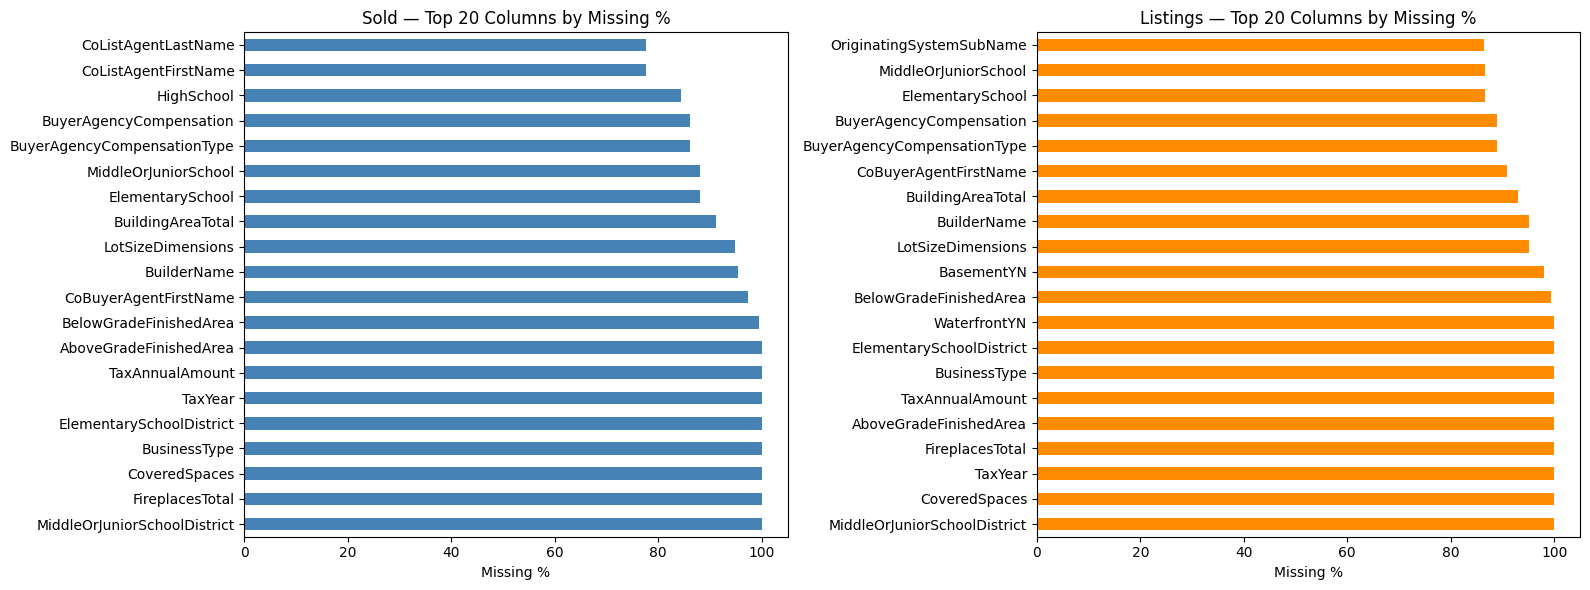

In [12]:
plot_missing_values(listings_missing, sold_missing)

We drop all columns with more than 90% missing values because none of the columns are one of the core variables like price, date, size, beds, baths, etc. These columns have no use to us if they are mostly empty.

In [13]:
# Drop columns with >90% missing
listings = listings.drop(columns=listing_cols_over_90_missing)

sold = sold.drop(columns=sold_cols_over_90_missing)

print(f"Sold shape: {sold.shape[0]:,} rows x {sold.shape[1]} columns")
print(f"Listings shape:      {listings.shape[0]:,} rows x {listings.shape[1]} columns")

Sold shape: 414,184 rows x 69 columns
Listings shape:      566,673 rows x 60 columns


### 2c) Change binary variables to 0s and 1s.

In [14]:
# Change YN columns to 0/1 Binary variables, with NaN = 0

YN_columns_listings = ['NewConstructionYN', 'FireplaceYN', 'AttachedGarageYN']

for col in YN_columns_listings:
    listings[col] = (
        listings[col]
        .replace({"Yes": 1, "No": 0})
        .fillna(0)
        .astype(int))

listings.head()

,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,ListAgentFirstName,ListAgentLastName,Latitude,Longitude,UnparsedAddress,...,HighSchool,Levels,LotSizeArea,MainLevelBedrooms,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet
0,1340000.0,1074973329,haleh360@Gmail.com,NaN,NaN,Haleh,Dowlatshahi,34.052207,-118.408445,2220 Avenue Of The Stars 2704,...,NaN,One,177861.0,NaN,0,NaN,NaN,90067,2105.00,177861.0
1,2500000.0,1074954552,Reneechen@yourhomesoldguaranteed.com,NaN,NaN,Renee,Chen,33.496363,-117.691677,16 Palisades,...,NaN,Two,5300.0,0.0,0,3.0,Capistrano Unified,92677,254.00,5300.0
2,3150000.0,1074936537,anader@dppre.com,NaN,NaN,Margaret,Nader,34.119345,-118.111254,1615 Waverly Road,...,NaN,Two,9404.0,NaN,0,2.0,NaN,91108,NaN,9404.0
3,3090000.0,1074917818,QIANYU0607@GMAIL.COM,NaN,NaN,QIANYU,GUAN,33.984057,-117.802819,2250 Indian Creek Road,...,Diamond Bar,ThreeOrMore,58232.0,1.0,0,4.0,Walnut Valley Unified,91765,295.95,58232.0
4,12725000.0,1074143166,jeff.williams@pacificsir.com,NaN,NaN,Jeff,Williams,33.607583,-117.887743,317 E. Bayfront,...,Corona Del Mar,ThreeOrMore,2250.0,3.0,0,2.0,Newport Mesa Unified,92662,0.00,2250.0


In [15]:
# Change YN columns to 0/1 Binary variables, with NaN = 0

YN_columns_sold = ['ViewYN', 'PoolPrivateYN', 'NewConstructionYN', 'FireplaceYN', 'AttachedGarageYN']

for col in YN_columns_sold:
    sold[col] = (
        sold[col]
        .replace({"True": 1, "False": 0})
        .fillna(0)
        .astype(int))

sold.head()

,BuyerAgentAOR,ListAgentAOR,Flooring,ViewYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,...,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,OriginatingSystemName,OriginatingSystemSubName,BuyerAgencyCompensationType,BuyerAgencyCompensation,latfilled,lonfilled
0,Mlslistings,Mlslistings,"Carpet,Tile,Wood",1,0,499000.0,551985747,jwachter@cbnorcal.com,2024-01-26,240000.0,...,Other,94401,6472.0,NaN,CRMLS,CRMLS_MLSL,NaN,NaN,NaN,NaN
1,SanDiego,SanDiego,NaN,0,0,759900.0,522107581,mdarwich12@gmail.com,2024-01-05,815000.0,...,NaN,91950,NaN,NaN,CRMLS,CRMLS_SAND,NaN,NaN,NaN,NaN
2,SanDiego,SanDiego,NaN,0,0,739900.0,510919001,mdarwich12@gmail.com,2024-01-05,810000.0,...,NaN,91950,NaN,NaN,CRMLS,CRMLS_SAND,NaN,NaN,NaN,NaN
3,Mlslistings,Mlslistings,NaN,0,0,NaN,1079166779,davidmartz@compass.com,2024-01-30,858000.0,...,Palm Springs Unified,92262,NaN,13504.0,CRMLS,CRMLS_MLSL,NaN,NaN,NaN,NaN
4,Southland,Southland,NaN,0,0,1890500.0,1075037759,karen.klein@theagencyre.com,2024-01-29,1890500.0,...,Los Angeles Unified,91356,0.0,17873.0,CRMLS,CRMLS_CRM,NaN,NaN,NaN,NaN


### 2d) Check distributions

In [16]:
target_columns = ["ClosePrice", "ListPrice","OriginalListPrice", "LivingArea", "LotSizeAcres", "BedroomsTotal", "BathroomsTotalInteger", "DaysOnMarket", "YearBuilt"]

#### i) Generate boxplots

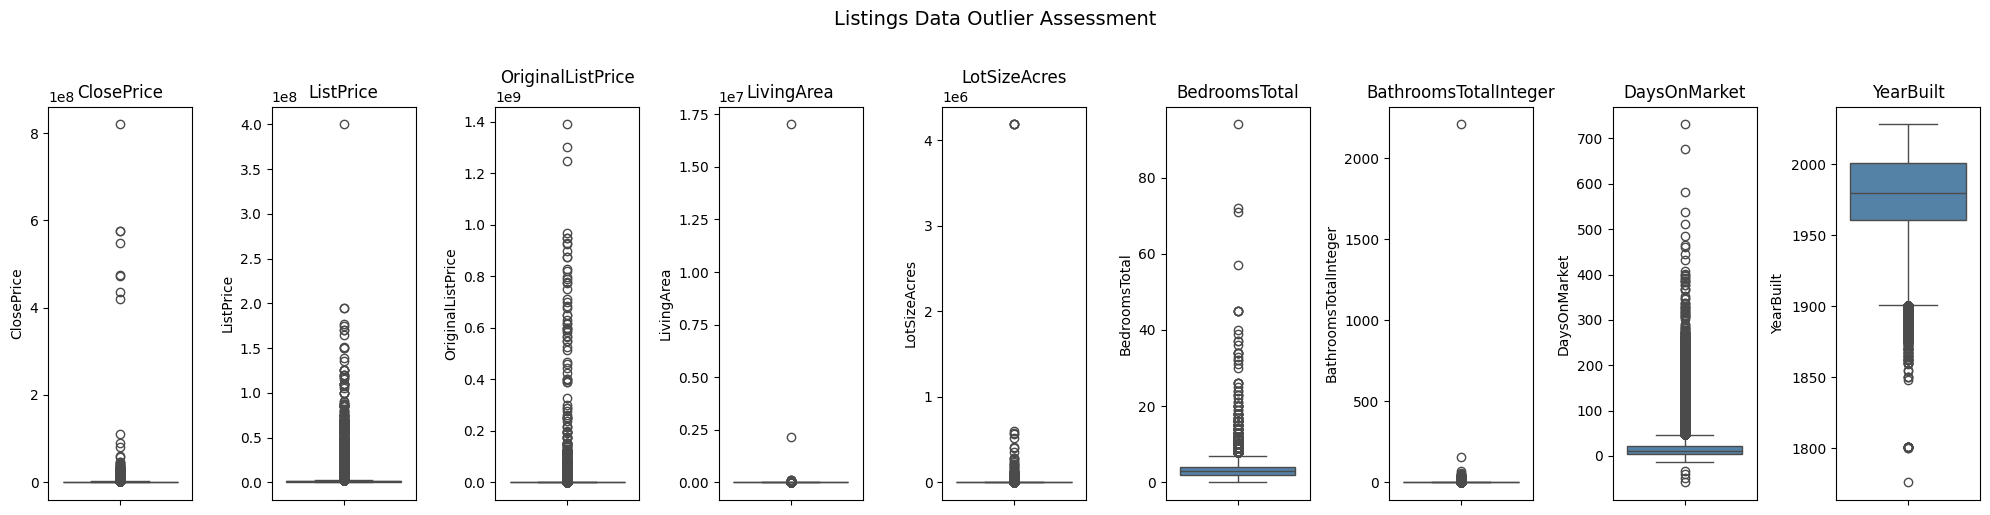

In [17]:
plot_boxplots(listings, target_columns, 'Listings Data Outlier Assessment', color = 'steelblue')

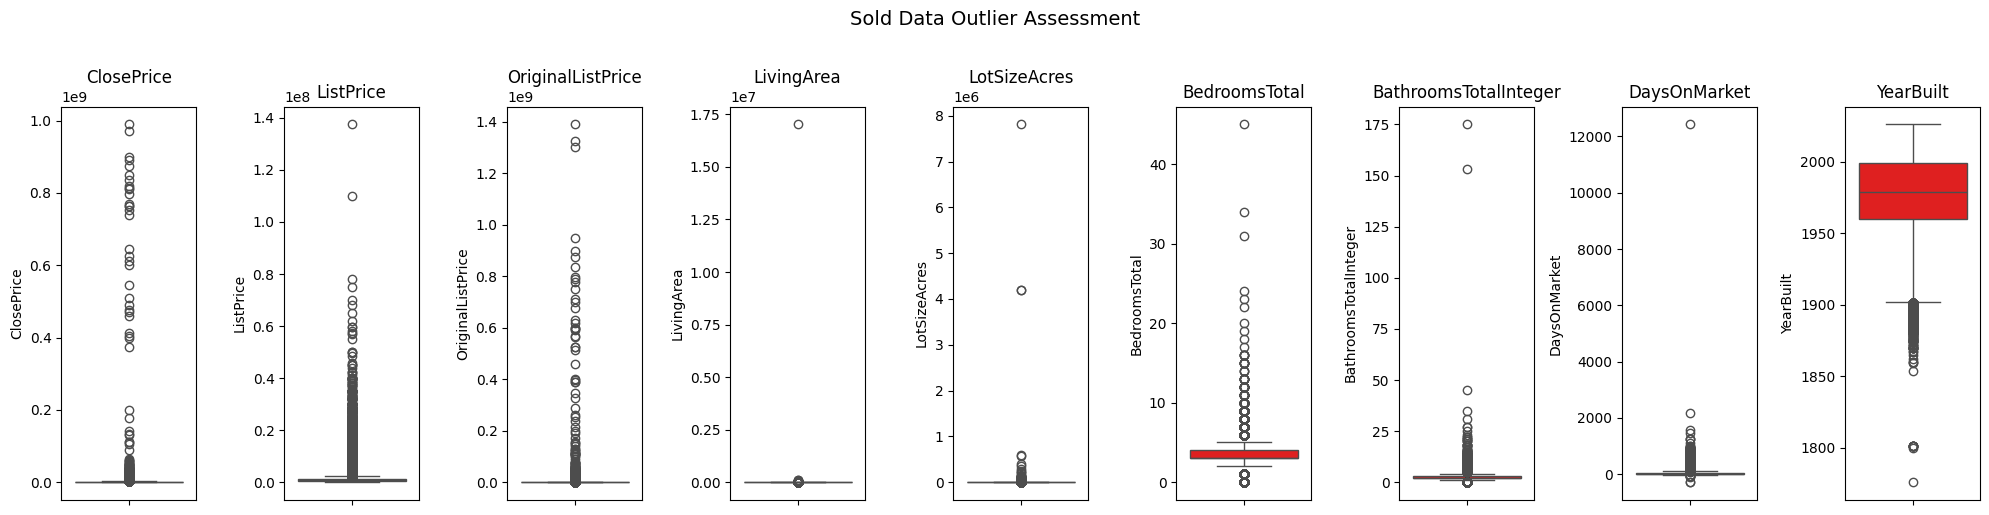

In [18]:
plot_boxplots(sold, target_columns, 'Sold Data Outlier Assessment', color = 'red')

#### ii) Generate histograms

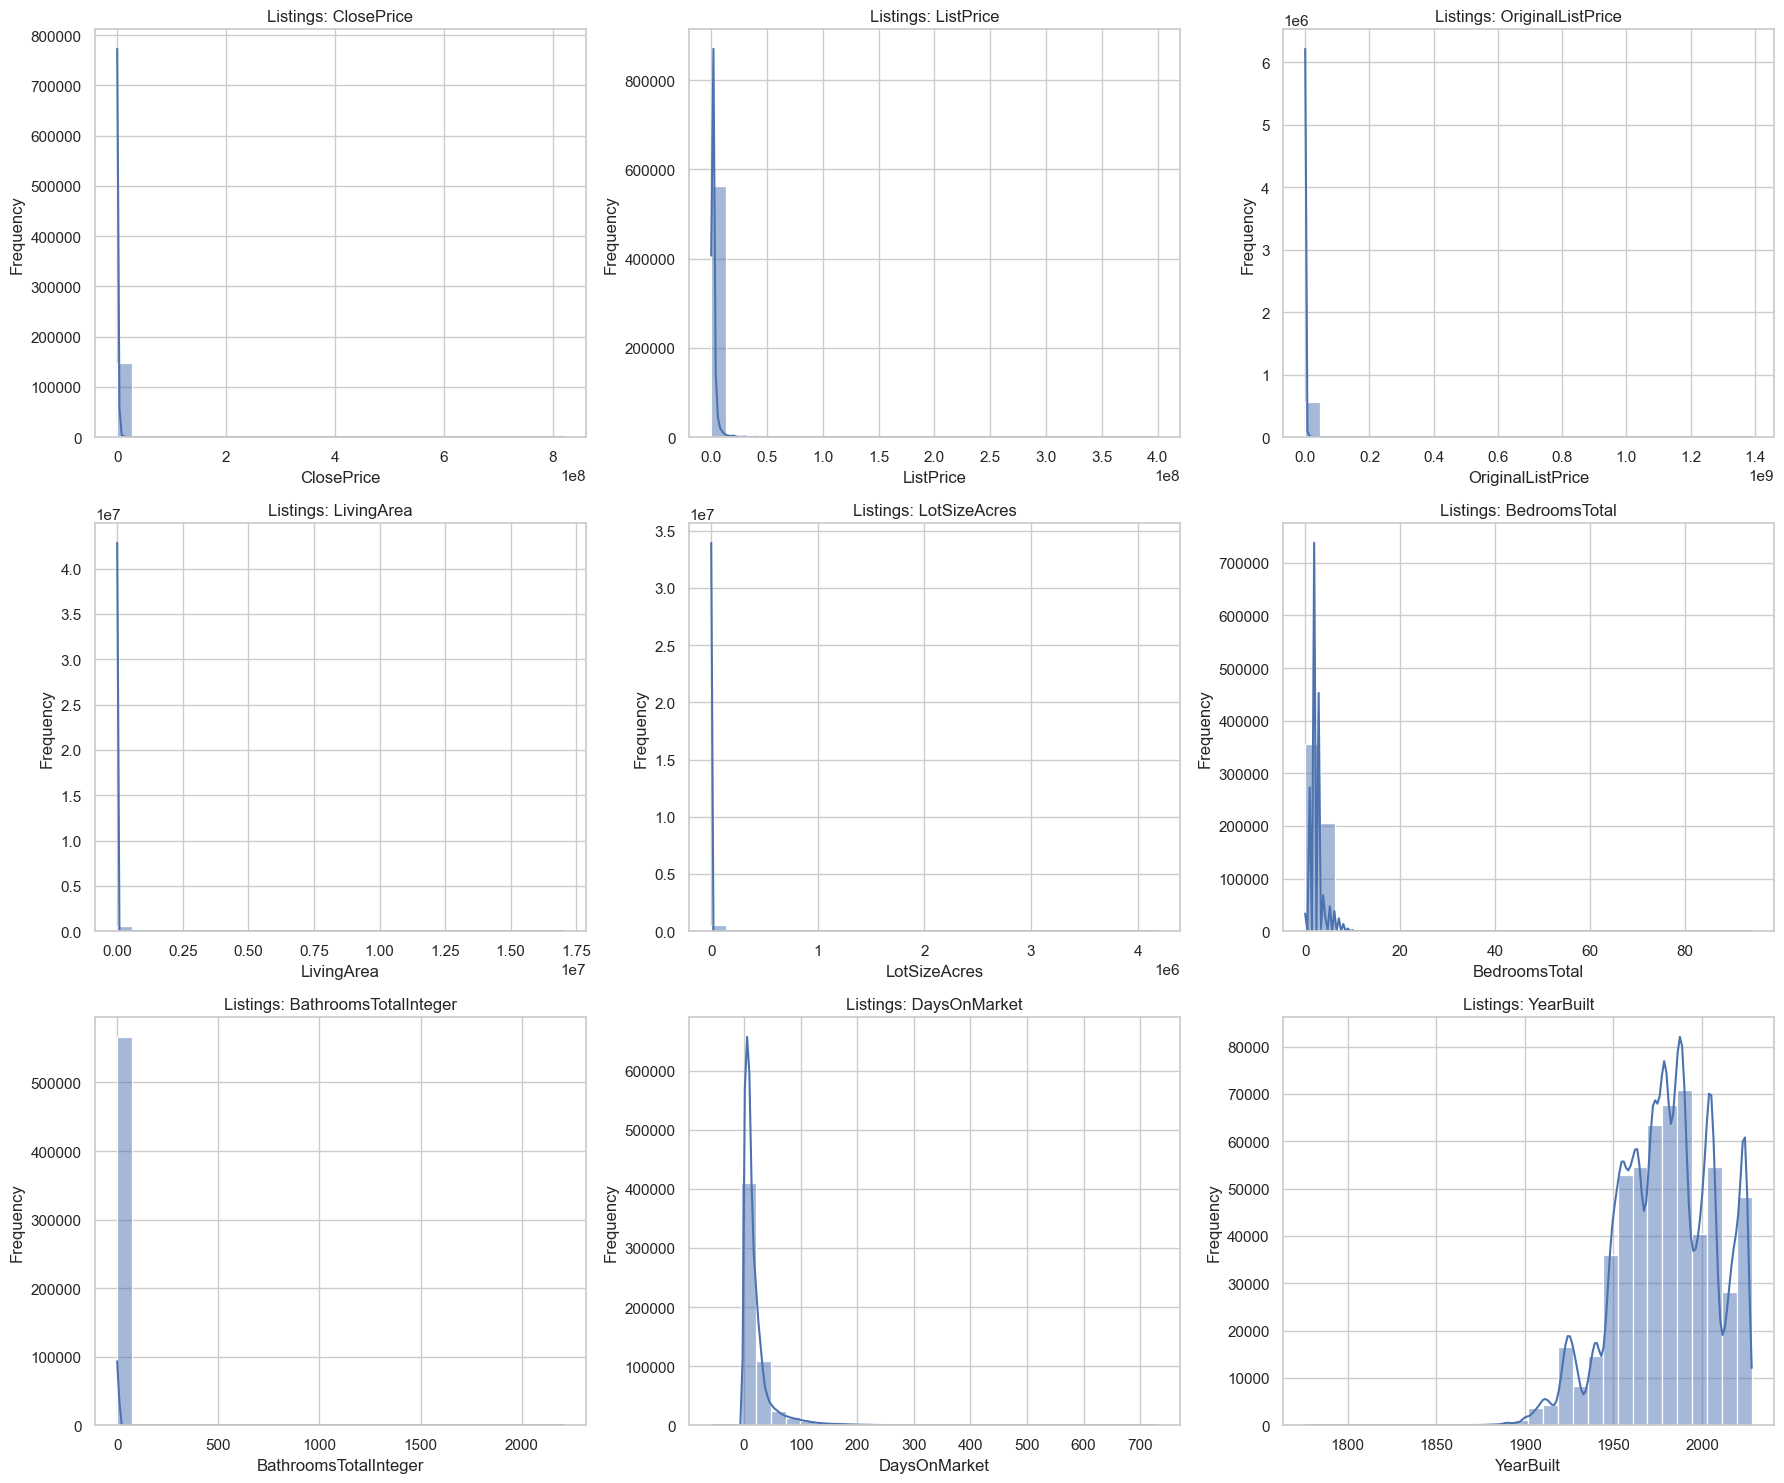

In [19]:
plot_histograms(listings, target_columns, "Listings")

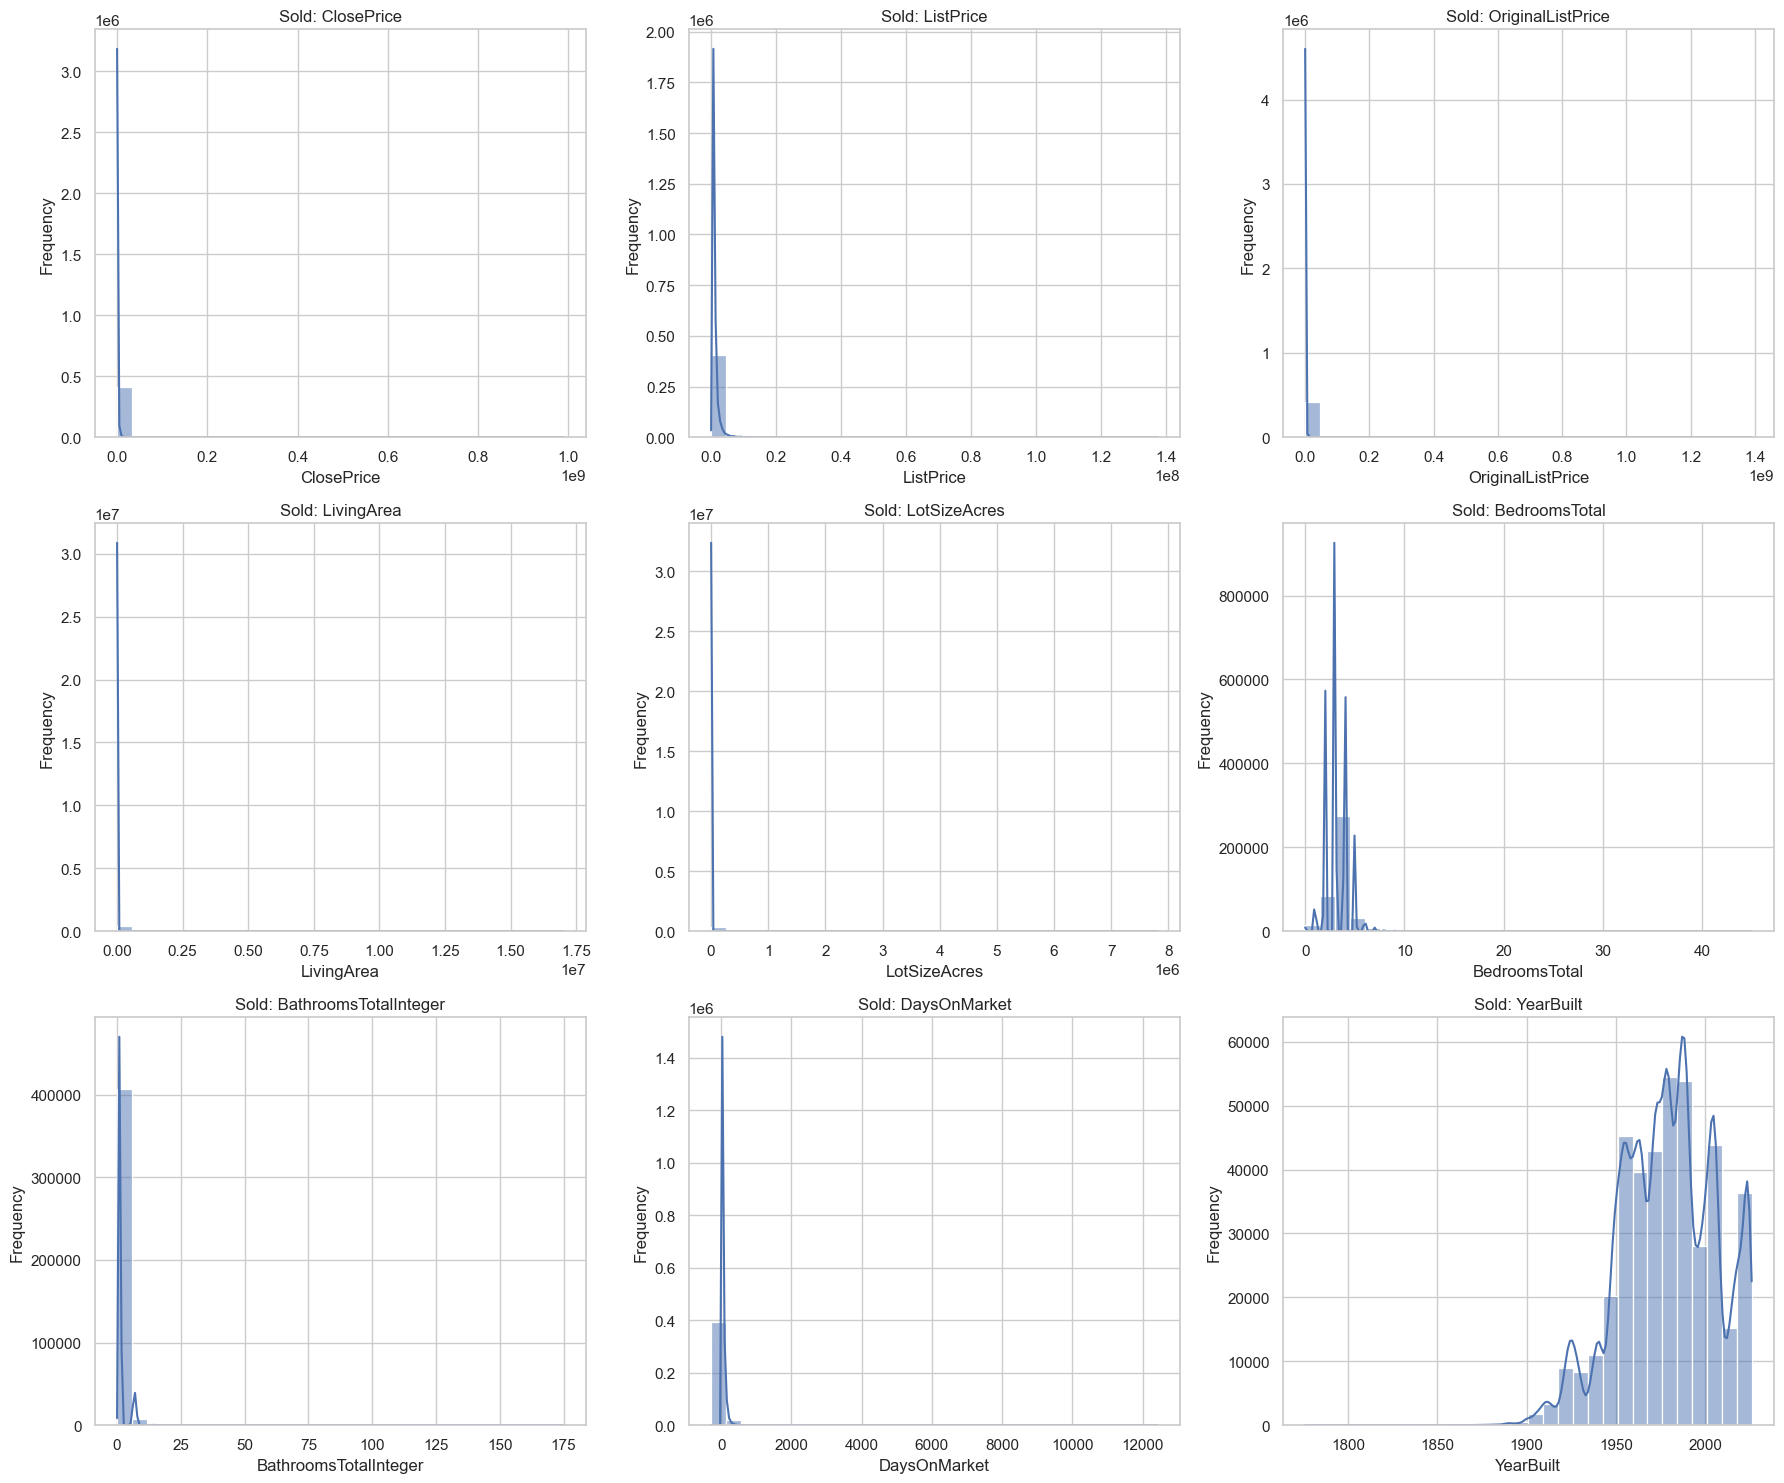

In [20]:
plot_histograms(sold, target_columns, "Sold")

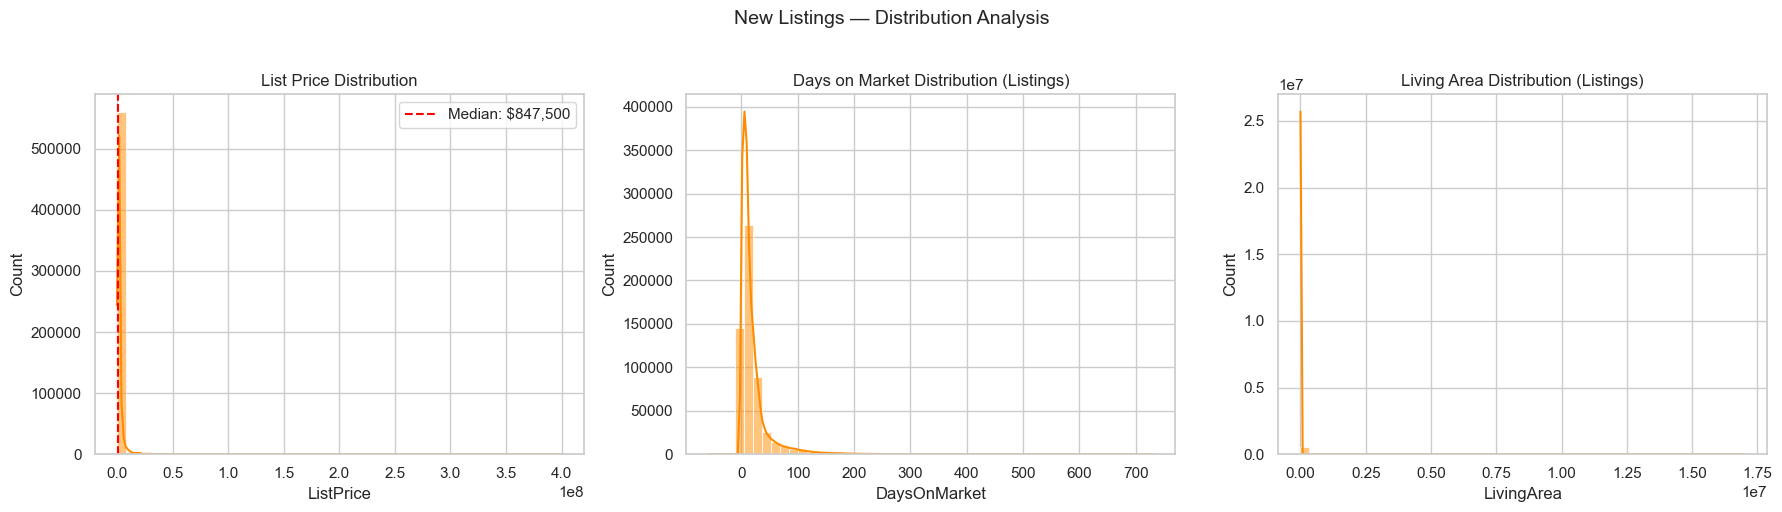

In [21]:
plot_listing_distributions(listings)

#### iv) Check for invalid numeric values and remove them from the dataset
- if ClosePrice <= 0
- if LivingArea <= 0
- if DaysOnMarket < 0
- if BathroomsTotalInteger < 0
- if BedroomsTotal < 0

In [22]:
# Check and remove invalid rows in listings
invalid_numeric_rows_listings = (
    (listings["ClosePrice"] <= 0) |
    (listings["LivingArea"] <= 0) |
    (listings["DaysOnMarket"] < 0) |
    (listings["BathroomsTotalInteger"] < 0) |
    (listings["BedroomsTotal"] < 0))

print(f"Listings rows meeting at least one invalid-condition check: {invalid_numeric_rows_listings.sum()}")

Listings rows meeting at least one invalid-condition check: 405


In [23]:
# Remove invalid rows
listings = listings[~invalid_numeric_rows_listings]

print(f"Listings shape after removing invalid rows: {listings.shape}")

Listings shape after removing invalid rows: (566268, 60)


In [24]:
# Check and remove invalid rows in listings
invalid_numeric_rows_sold = (
    (sold["ClosePrice"] <= 0) |
    (sold["LivingArea"] <= 0) |
    (sold["DaysOnMarket"] < 0) |
    (sold["BathroomsTotalInteger"] < 0) |
    (sold["BedroomsTotal"] < 0))

print(f"Sold rows meeting at least one invalid-condition check: {invalid_numeric_rows_sold.sum()}")

Sold rows meeting at least one invalid-condition check: 198


In [25]:
# Remove invalid rows

sold = sold[~invalid_numeric_rows_sold]

print(f"Sold shape: {sold.shape[0]:,} rows x {sold.shape[1]} columns")

Sold shape: 413,986 rows x 69 columns


# 3. Feature Engineering

### 3a) Mortgage Rate Enrichment

Step 1: Fetch the mortgage rate data from FRED

In [26]:
# Libraries required to import the url file
import requests
import io
import certifi

url = "https://fred.stlouisfed.org/graph/fredgraph.csv?id=MORTGAGE30US"

# Import the mortgage file
response = requests.get(url, verify=certifi.where())
response.raise_for_status()

mortgage = pd.read_csv(io.StringIO(response.text), parse_dates=["observation_date"])
mortgage.columns = ['date', 'rate_30yr_fixed']

Step 2: Resample weekly rates to monthly averages

In [27]:
mortgage['year_month'] = mortgage['date'].dt.to_period('M')
mortgage_monthly = (
 mortgage.groupby('year_month')['rate_30yr_fixed']
 .mean()
 .reset_index())

# Check
mortgage.head()

,date,rate_30yr_fixed,year_month
0,1971-04-02,7.33,1971-04
1,1971-04-09,7.31,1971-04
2,1971-04-16,7.31,1971-04
3,1971-04-23,7.31,1971-04
4,1971-04-30,7.29,1971-04


Step 3: Create a matching year_month key on the MLS datasets

In [28]:
# Sold dataset — key off CloseDate
sold['year_month'] = pd.to_datetime(sold['CloseDate']).dt.to_period('M')

# Listings dataset — key off ListingContractDate
listings['year_month'] = pd.to_datetime(listings['ListingContractDate']).dt.to_period('M')

Step 4: Merge

In [29]:
sold = sold.merge(mortgage_monthly, on='year_month', how='left')

listings = listings.merge(mortgage_monthly, on='year_month', how='left')

Step 5: Validate the merge

In [30]:
# Check for any unmatched rows (rate should not be null)
print(sold['rate_30yr_fixed'].isnull().sum())
print(listings['rate_30yr_fixed'].isnull().sum())

# Preview
print(sold[['CloseDate', 'year_month', 'ClosePrice', 'rate_30yr_fixed']].head())

0
0
    CloseDate year_month  ClosePrice  rate_30yr_fixed
0  2024-01-26    2024-01    240000.0           6.6425
1  2024-01-05    2024-01    815000.0           6.6425
2  2024-01-05    2024-01    810000.0           6.6425
3  2024-01-30    2024-01    858000.0           6.6425
4  2024-01-29    2024-01   1890500.0           6.6425


### 3b) Date Time features
Create year/month features from date columns

In [31]:
# Listings date columns

listings_date_cols = [col for col in listings.columns if "date" in col.lower()]
print("Listings Date Columns", listings_date_cols)

Listings Date Columns ['CloseDate', 'ContractStatusChangeDate', 'PurchaseContractDate', 'ListingContractDate']


In [32]:
# Create the Listings date features

for col in listings_date_cols:
    listings[col] = pd.to_datetime(listings[col], errors="coerce")
    base_name = col.replace("Date", "").lower()

    listings[f"{base_name}_year"] = listings[col].dt.year
    listings[f"{base_name}_month"] = listings[col].dt.month
    listings[f"{base_name}_day"] = listings[col].dt.day
    listings[f"{base_name}_yrmoday"] = (
        listings[f"{base_name}_year"] * 10000
        + listings[f"{base_name}_month"] * 100
        + listings[f"{base_name}_day"])
    listings[f"{base_name}_yrmo"] = (
        listings[f"{base_name}_year"] * 100
        + listings[f"{base_name}_month"] * 1)

    print(f"{col} date range:", listings[col].min().date(), "to", listings[col].max().date())

CloseDate date range: 2024-01-01 to 2030-04-16
ContractStatusChangeDate date range: 2024-01-01 to 2026-06-30
PurchaseContractDate date range: 2023-06-13 to 2026-05-06
ListingContractDate date range: 2024-01-01 to 2026-04-30


In [33]:
# Sold date columns

sold_date_cols = [col for col in sold.columns if "date" in col.lower()]
print("Sold Date Columns", sold_date_cols)

Sold Date Columns ['CloseDate', 'ContractStatusChangeDate', 'PurchaseContractDate', 'ListingContractDate']


In [34]:
# Create the Sold date features

for col in sold_date_cols:
    sold[col] = pd.to_datetime(sold[col], errors="coerce")
    base_name = col.replace("Date", "").lower()

    sold[f"{base_name}_year"] = sold[col].dt.year
    sold[f"{base_name}_month"] = sold[col].dt.month
    sold[f"{base_name}_day"] = sold[col].dt.day
    sold[f"{base_name}_yrmoday"] = (
        sold[f"{base_name}_year"] * 10000
        + sold[f"{base_name}_month"] * 100
        + sold[f"{base_name}_day"])
    sold[f"{base_name}_yrmo"] = (
        sold[f"{base_name}_year"] * 100
        + sold[f"{base_name}_month"] * 1)

    print(f"{col} date range:", sold[col].min().date(), "to", sold[col].max().date())

CloseDate date range: 2024-01-01 to 2026-04-30
ContractStatusChangeDate date range: 2024-01-01 to 2026-04-30
PurchaseContractDate date range: 1923-11-16 to 2026-04-30
ListingContractDate date range: 1984-08-28 to 2026-05-01


#### i) Date Consistency Checks
Are there any apparent date consistency issues (e.g., close date before listing date)?

In [35]:
listing_date_consistency_checks = {
    # Is the close date before the listing date?
    "CloseDate before ListingContractDate": listings["close_yrmoday"] < listings["listingcontract_yrmoday"],

    # Is the purchase contract date before the listing date?
    "PurchaseContractDate before ListingContractDate": listings["purchasecontract_yrmoday"] < listings["listingcontract_yrmoday"],

    # Is the close date before the purchase contract date?
    "CloseDate before PurchaseContractDate": listings["close_yrmoday"] < listings["purchasecontract_yrmoday"],

    # Is the contract status change date before the listing date?
    "ContractStatusChangeDate before ListingContractDate": listings["contractstatuschange_yrmoday"] < listings["listingcontract_yrmoday"],}

print("\nListings date consistency checks:")
for check_name, condition in listing_date_consistency_checks.items():
    print(f"{check_name}: {condition.sum()} rows")


Listings date consistency checks:
CloseDate before ListingContractDate: 74 rows
PurchaseContractDate before ListingContractDate: 276 rows
CloseDate before PurchaseContractDate: 266 rows
ContractStatusChangeDate before ListingContractDate: 131 rows


We should drop the rows with these date inconsistencies before further analysis to avoid tainting the results.

In [36]:
sold_date_consistency_checks = {
    # Is the close date before the listing date?
    "CloseDate before ListingContractDate": sold["close_yrmoday"] < sold["listingcontract_yrmoday"],

    # Is the purchase contract date before the listing date?
    "PurchaseContractDate before ListingContractDate": sold["purchasecontract_yrmoday"] < sold["listingcontract_yrmoday"],

    # Is the close date before the purchase contract date?
    "CloseDate before PurchaseContractDate": sold["close_yrmoday"] < sold["purchasecontract_yrmoday"],

    # Is the contract status change date before the listing date?
    "ContractStatusChangeDate before ListingContractDate": sold["contractstatuschange_yrmoday"] < sold["listingcontract_yrmoday"],}

print("Sold date consistency checks:")
for check_name, condition in sold_date_consistency_checks.items():
    print(f"{check_name}: {condition.sum()} rows")

Sold date consistency checks:
CloseDate before ListingContractDate: 61 rows
PurchaseContractDate before ListingContractDate: 269 rows
CloseDate before PurchaseContractDate: 240 rows
ContractStatusChangeDate before ListingContractDate: 61 rows


In [37]:
# Drop inconsistent date rows for Listings

bad_date_rows_listings = (
    (listings["close_yrmoday"] < listings["listingcontract_yrmoday"]) |
    (listings["purchasecontract_yrmoday"] < listings["listingcontract_yrmoday"]) |
    (listings["close_yrmoday"] < listings["purchasecontract_yrmoday"]) |
    (listings["contractstatuschange_yrmoday"] < listings["listingcontract_yrmoday"]))

print(f"Rows in Listings with date inconsistencies: {bad_date_rows_listings.sum()}")

# Remove inconsistent date rows
listings = listings[~bad_date_rows_listings]

Rows in Listings with date inconsistencies: 544


In [38]:
# Drop inconsistent date rows for Sold

bad_date_rows_sold = (
    (sold["close_yrmoday"] < sold["listingcontract_yrmoday"]) |
    (sold["purchasecontract_yrmoday"] < sold["listingcontract_yrmoday"]) |
    (sold["close_yrmoday"] < sold["purchasecontract_yrmoday"]) |
    (sold["contractstatuschange_yrmoday"] < sold["listingcontract_yrmoday"]))

print(f"Rows in Sold with date inconsistencies: {bad_date_rows_sold.sum()}")

# Remove inconsistent date rows
sold = sold[~bad_date_rows_sold]

Rows in Sold with date inconsistencies: 509


### 3c) Geographic data checks
Flag rows with missing coordinates, latitude or longitude = 0, longitude > 0, and out-of-state or implausible coordinates.

The plausible range for coordinates for California are as follows:
- Latitude = 32 to 42 degrees
- Longitude = -125 to -114 degrees

In [39]:
# Ranges for plausible California coordinates
min_lat = 32
max_lat = 42
min_long = -125
max_long = -114

# Function for checking each geographic consistency
def geographic_consistency_check(df, df_name):
    null_lat = df["Latitude"].isna()
    null_long = df["Longitude"].isna()

    lat_zero = df["Latitude"] == 0
    long_zero = df["Longitude"] == 0

    long_positive = df["Longitude"] > 0

    lat_out_of_range = (df["Latitude"] < min_lat) | (df["Latitude"] > max_lat)
    long_out_of_range = (df["Longitude"] < min_long) | (df["Longitude"] > max_long)

    print(f"{df_name} Geographic Consistency Checks:")
    print(f"Null Latitude: {null_lat.sum()} rows")
    print(f"Null Longitude: {null_long.sum()} rows")
    print(f"Latitude = 0: {lat_zero.sum()} rows")
    print(f"Longitude = 0: {long_zero.sum()} rows")
    print(f"Longitude > 0: {long_positive.sum()} rows")
    print(f"Latitude outside plausible CA range: {lat_out_of_range.sum()} rows")
    print(f"Longitude outside plausible CA range: {long_out_of_range.sum()} rows")

    any_geo_inconsistencies = (null_lat | null_long | lat_zero | long_zero | long_positive | lat_out_of_range | long_out_of_range)

    print(f"Rows with any geographic inconsistencies: {any_geo_inconsistencies.sum()} rows")

    return any_geo_inconsistencies

In [40]:
# Listings geographic check
listings_geo_check = geographic_consistency_check(listings, "Listings")

Listings Geographic Consistency Checks:
Null Latitude: 80255 rows
Null Longitude: 80255 rows
Latitude = 0: 65 rows
Longitude = 0: 65 rows
Longitude > 0: 86 rows
Latitude outside plausible CA range: 200 rows
Longitude outside plausible CA range: 263 rows
Rows with any geographic inconsistencies: 80555 rows


In [41]:
# Sold geographic check
sold_geo_check = geographic_consistency_check(sold, "Sold")

Sold Geographic Consistency Checks:
Null Latitude: 15869 rows
Null Longitude: 15869 rows
Latitude = 0: 27 rows
Longitude = 0: 27 rows
Longitude > 0: 31 rows
Latitude outside plausible CA range: 48 rows
Longitude outside plausible CA range: 81 rows
Rows with any geographic inconsistencies: 15957 rows


I've decided simply to flag the inconsistent geographic rows instead of dropping them, since those rows may still contain useful information in other analysis columns. However, for my analyses on strictly geographical features, I will be dropping the invalid rows.

# 4. Outlier Detection

#### 4a) Generate percentile summaries

Each percentile tells us where a listing falls relative to the rest of the market for that variable.
General meaning of each percentile:
- 1% = extremely low end of the market, helps identify unusually small, cheap, or suspicious observations
- 5% = low end of the market but less extreme, useful for understanding the lower tail without focusing only on the most unusual cases
- 25% = 1st quartile; lower end of the typical range, often a good benchmark for what counts as relatively small
- 50% = median; half the listings are below it and half are above it, more useful than the mean when the data is skewed
- 75% = 3rd quartile; upper end of the typical range, helps identify what counts as relatively high
- 95% = very high end of the market, only 5% of listings are above this; useful for identifying luxury or unusually large/expensive properties without jumping all the way to the max
- 99% = extreme upper tail, only 1% of listings are above this; used to identify extreme outliers or ultra-luxury properties

In [42]:
listing_cols = [col for col in target_columns if col in listings.columns]

listing_percentiles = listings[listing_cols].describe(
    percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T

print("Listings Percentile Summary")
listing_percentiles

Listings Percentile Summary


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
ClosePrice,146150.0,1.202340e+06,4.285616e+06,525.0,215000.0,355000.0000,600000.00,855000.00,1.350000e+06,2.900000e+06,5.500000e+06,8.200000e+08
ListPrice,565724.0,1.314157e+06,2.401043e+06,100.0,214900.0,346000.0000,580000.00,845000.00,1.379000e+06,3.450000e+06,8.193390e+06,4.000000e+08
OriginalListPrice,565115.0,1.397153e+06,7.280535e+06,0.0,200000.0,348888.0000,585000.00,849000.00,1.390000e+06,3.495000e+06,8.499999e+06,1.390000e+09
LivingArea,565146.0,1.981921e+03,2.285036e+04,1.0,593.0,820.0000,1248.00,1671.00,2.302000e+03,3.872000e+03,6.305000e+03,1.702132e+07
LotSizeAcres,519193.0,6.306988e+01,1.186013e+04,0.0,0.0,0.0287,0.12,0.17,3.146000e-01,3.589900e+00,1.349950e+01,4.187292e+06
BedroomsTotal,565651.0,3.225565e+00,1.186061e+00,0.0,1.0,2.0000,2.00,3.00,4.000000e+00,5.000000e+00,6.000000e+00,9.400000e+01
BathroomsTotalInteger,565667.0,2.629049e+00,3.194224e+00,0.0,1.0,1.0000,2.00,2.00,3.000000e+00,5.000000e+00,7.000000e+00,2.208000e+03
DaysOnMarket,565724.0,1.912200e+01,2.631472e+01,0.0,0.0,0.0000,5.00,11.00,2.200000e+01,6.900000e+01,1.370000e+02,7.310000e+02
YearBuilt,564797.0,1.979670e+03,2.699940e+01,1776.0,1911.0,1929.0000,1961.00,1980.00,2.001000e+03,2.023000e+03,2.025000e+03,2.028000e+03


In [43]:
sold_cols = [col for col in target_columns if col in sold.columns]

sold_percentiles = sold[sold_cols].describe(
    percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T

print("Sold Percentile Summary")
sold_percentiles

Sold Percentile Summary


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
ClosePrice,413475.0,1.189068e+06,6.143281e+06,1.15,203000.0,340000.00,575000.00,821000.0000,1.300000e+06,2850000.00,5.550000e+06,9.895000e+08
ListPrice,413477.0,1.138502e+06,1.351120e+06,525.00,214999.0,347000.00,575175.00,815000.0000,1.295000e+06,2850000.00,5.695000e+06,1.375000e+08
OriginalListPrice,412916.0,1.223885e+06,6.711266e+06,0.00,210075.0,349900.00,585000.00,825000.0000,1.299000e+06,2899000.00,5.995000e+06,1.390000e+09
LivingArea,413243.0,1.904480e+03,2.649463e+04,1.00,609.0,840.00,1248.00,1643.0000,2.219000e+03,3560.00,5.281000e+03,1.702132e+07
LotSizeAcres,381011.0,6.638910e+01,1.600884e+04,0.00,0.0,0.03,0.12,0.1664,2.728000e-01,2.82,1.083350e+01,7.810698e+06
BedroomsTotal,413466.0,3.201470e+00,1.066369e+00,0.00,1.0,2.00,3.00,3.0000,4.000000e+00,5.00,6.000000e+00,4.500000e+01
BathroomsTotalInteger,413408.0,2.534801e+00,1.132228e+00,0.00,1.0,1.00,2.00,2.0000,3.000000e+00,4.00,6.000000e+00,1.750000e+02
DaysOnMarket,413477.0,3.740567e+01,5.360269e+01,0.00,0.0,2.00,8.00,18.0000,4.800000e+01,132.00,2.310000e+02,1.243000e+04
YearBuilt,413132.0,1.978597e+03,2.627048e+01,1776.00,1912.0,1930.00,1960.00,1979.0000,1.999000e+03,2022.00,2.025000e+03,2.026000e+03


#### 4b) Identify extreme outliers using IQR method


In [44]:
# Outliers in Listings

for col in target_columns:
    if col in listings.columns:
        listings = flag_outliers(listings, col)

ClosePrice: 10,530 outliers flagged (1.9%) — bounds [-525,000.00, 2,475,000.00]
ListPrice: 47,548 outliers flagged (8.4%) — bounds [-618,500.00, 2,577,500.00]
OriginalListPrice: 47,515 outliers flagged (8.4%) — bounds [-622,500.00, 2,597,500.00]
LivingArea: 27,952 outliers flagged (4.9%) — bounds [-333.00, 3,883.00]
LotSizeAcres: 83,267 outliers flagged (14.7%) — bounds [-0.17, 0.61]
BedroomsTotal: 1,832 outliers flagged (0.3%) — bounds [-1.00, 7.00]
BathroomsTotalInteger: 35,718 outliers flagged (6.3%) — bounds [0.50, 4.50]
DaysOnMarket: 49,191 outliers flagged (8.7%) — bounds [-20.50, 47.50]
YearBuilt: 1,414 outliers flagged (0.2%) — bounds [1,901.00, 2,061.00]


In [45]:
# Outliers for Sold

for col in target_columns:
    if col in sold.columns:
        sold = flag_outliers(sold, col)

ClosePrice: 30,600 outliers flagged (7.4%) — bounds [-512,500.00, 2,387,500.00]
ListPrice: 30,881 outliers flagged (7.5%) — bounds [-504,562.50, 2,374,737.50]
OriginalListPrice: 32,132 outliers flagged (7.8%) — bounds [-486,000.00, 2,370,000.00]
LivingArea: 18,183 outliers flagged (4.4%) — bounds [-208.50, 3,675.50]
LotSizeAcres: 59,285 outliers flagged (14.3%) — bounds [-0.11, 0.50]
BedroomsTotal: 22,638 outliers flagged (5.5%) — bounds [1.50, 5.50]
BathroomsTotalInteger: 18,932 outliers flagged (4.6%) — bounds [0.50, 4.50]
DaysOnMarket: 31,796 outliers flagged (7.7%) — bounds [-52.00, 108.00]
YearBuilt: 972 outliers flagged (0.2%) — bounds [1,901.50, 2,057.50]


#### 4c) Remove outliers

##### BedroomsTotal and BathroomsTotalInteger
The columns that we can use IQR method to remove outliers are BedroomsTotal and BathroomsTotalInteger, since logically these values should all fall between 1-6, and anything larger than 10 would probably be errors.

In [46]:
# Remove outliers with IQR method - Sold dataset

sold = filter_outliers(sold, ["BedroomsTotal", "BathroomsTotalInteger"])

BedroomsTotal: 22,638 outliers flagged (5.5%) — bounds [1.50, 5.50]
BathroomsTotalInteger: 18,932 outliers flagged (4.6%) — bounds [0.50, 4.50]

Original rows: 413,477 | After filtering: 376,416 | Removed: 37,061


In [47]:
# Remove outliers with IQR method - Listings dataset

listings = filter_outliers(listings, ["BedroomsTotal", "BathroomsTotalInteger"])

BedroomsTotal: 1,832 outliers flagged (0.3%) — bounds [-1.00, 7.00]
BathroomsTotalInteger: 35,718 outliers flagged (6.3%) — bounds [0.50, 4.50]

Original rows: 565,724 | After filtering: 529,729 | Removed: 35,995


##### Price Columns: ClosePrice, ListPrice, OriginalListPrice

For ClosePrice, the minimum is 1.15, which is definitely a data entry error, so for this variable, we remove all outliers below the 1st percentile or above the 99th percentile. We don't apply IQR method because there may be listings that are ultra-luxurious and truly do have an extremely high close price.

We apply the same method to ListPrice and OriginalListPrice.

In [48]:
# Close Price - Sold

print(f"Original Sold shape: {sold.shape[0]:,} rows x {sold.shape[1]} columns")

# Define the percentile bounds
p1_closeprice_sold = sold["ClosePrice"].quantile(0.01)

p99_closeprice_sold = sold["ClosePrice"].quantile(0.99)

# Remove the extreme outliers
sold = sold[(sold["ClosePrice"] >= p1_closeprice_sold) & (sold["ClosePrice"] <= p99_closeprice_sold)]

# Check new shape for sold
print(f"New Sold shape: {sold.shape[0]:,} rows x {sold.shape[1]} columns")

Original Sold shape: 376,416 rows x 100 columns
New Sold shape: 368,982 rows x 100 columns


In [49]:
# Close Price - Listings

print(f"Original Listings shape: {listings.shape[0]:,} rows x {listings.shape[1]} columns")

# Define the percentile bounds
p1_closeprice_listings = listings["ClosePrice"].quantile(0.01)

p99_closeprice_listings = listings["ClosePrice"].quantile(0.99)

# Remove the extreme outliers
listings = listings[(listings["ClosePrice"] >= p1_closeprice_listings) & (listings["ClosePrice"] <= p99_closeprice_listings)]

# Check new shape for listings
print(f"New Listings shape: {listings.shape[0]:,} rows x {listings.shape[1]} columns")

Original Listings shape: 529,729 rows x 91 columns
New Listings shape: 137,314 rows x 91 columns


In [50]:
# List Price - Sold

print(f"Original Sold shape: {sold.shape[0]:,} rows x {sold.shape[1]} columns")

# Define the percentile bounds
p1_listprice = sold["ListPrice"].quantile(0.01)

p99_listprice = sold["ListPrice"].quantile(0.99)

# Remove the extreme outliers
sold = sold[(sold["ListPrice"] >= p1_listprice) & (sold["ListPrice"] <= p99_listprice)]

# Check new shape for sold
print(f"New Sold shape: {sold.shape[0]:,} rows x {sold.shape[1]} columns")

Original Sold shape: 368,982 rows x 100 columns
New Sold shape: 362,027 rows x 100 columns


In [51]:
# List Price - Listings

print(f"Original Listings shape: {listings.shape[0]:,} rows x {listings.shape[1]} columns")

# Define the percentile bounds
p1_listprice_listings = listings["ListPrice"].quantile(0.01)

p99_listprice_listings = listings["ListPrice"].quantile(0.99)

# Remove the extreme outliers
listings = listings[(listings["ListPrice"] >= p1_listprice_listings) & (listings["ListPrice"] <= p99_listprice_listings)]

# Check new shape for listings
print(f"New Listings shape: {listings.shape[0]:,} rows x {listings.shape[1]} columns")

Original Listings shape: 137,314 rows x 91 columns
New Listings shape: 134,606 rows x 91 columns


In [52]:
# Original List Price - Sold

print(f"Original Sold shape: {sold.shape[0]:,} rows x {sold.shape[1]} columns")

# Define the percentile bounds
p1_oglistprice = sold["OriginalListPrice"].quantile(0.01)

p99_oglistprice = sold["OriginalListPrice"].quantile(0.99)

# Remove the extreme outliers
sold = sold[(sold["OriginalListPrice"] >= p1_oglistprice) & (sold["OriginalListPrice"] <= p99_oglistprice)]

# Check new shape for sold
print(f"New Sold shape: {sold.shape[0]:,} rows x {sold.shape[1]} columns")

Original Sold shape: 362,027 rows x 100 columns
New Sold shape: 354,579 rows x 100 columns


In [53]:
# Original List Price - Listings

print(f"Original Listings shape: {listings.shape[0]:,} rows x {listings.shape[1]} columns")

# Define the percentile bounds
p1_oglistprice_listings = listings["OriginalListPrice"].quantile(0.01)

p99_oglistprice_listings = listings["OriginalListPrice"].quantile(0.99)

# Remove the extreme outliers
listings = listings[(listings["OriginalListPrice"] >= p1_oglistprice_listings) & (listings["OriginalListPrice"] <= p99_oglistprice_listings)]

# Check new shape for listings
print(f"New Listings shape: {listings.shape[0]:,} rows x {listings.shape[1]} columns")

Original Listings shape: 134,606 rows x 91 columns
New Listings shape: 131,509 rows x 91 columns


##### LivingArea and LotSizeAcres

Let's apply the same rule as the price columns to these columns, with the same reasoning.

In [54]:
# Living Area - Sold

print(f"Original Sold shape: {sold.shape[0]:,} rows x {sold.shape[1]} columns")

# Define the percentile bounds
p1_livingarea = sold["LivingArea"].quantile(0.01)

p99_livingarea = sold["LivingArea"].quantile(0.99)

# Remove the extreme outliers
sold = sold[(sold["LivingArea"] >= p1_livingarea) & (sold["LivingArea"] <= p99_livingarea)]

# Check new shape for sold
print(f"New Sold shape: {sold.shape[0]:,} rows x {sold.shape[1]} columns")

Original Sold shape: 354,579 rows x 100 columns
New Sold shape: 347,444 rows x 100 columns


In [55]:
# Living Area - Listings

print(f"Original Listings shape: {listings.shape[0]:,} rows x {listings.shape[1]} columns")

# Define the percentile bounds
p1_livingarea_listings = listings["LivingArea"].quantile(0.01)

p99_livingarea_listings = listings["LivingArea"].quantile(0.99)

# Remove the extreme outliers
listings = listings[(listings["LivingArea"] >= p1_livingarea_listings) & (listings["LivingArea"] <= p99_livingarea_listings)]

# Check new shape for sold
print(f"New Listings shape: {listings.shape[0]:,} rows x {listings.shape[1]} columns")

Original Listings shape: 131,509 rows x 91 columns
New Listings shape: 128,857 rows x 91 columns


In [56]:
# Lot Size Acres - Sold

print(f"Original Sold shape: {sold.shape[0]:,} rows x {sold.shape[1]} columns")

# Define the percentile bounds
p1_lotsize = sold["LotSizeAcres"].quantile(0.01)

p99_lotsize = sold["LotSizeAcres"].quantile(0.99)

# Remove the extreme outliers
sold = sold[(sold["LotSizeAcres"] >= p1_lotsize) & (sold["LotSizeAcres"] <= p99_lotsize)]

# Check new shape for sold
print(f"New Sold shape: {sold.shape[0]:,} rows x {sold.shape[1]} columns")

Original Sold shape: 347,444 rows x 100 columns
New Sold shape: 317,273 rows x 100 columns


In [57]:
# Lot Size Acres - Listings

print(f"Original Listings shape: {listings.shape[0]:,} rows x {listings.shape[1]} columns")

# Define the percentile bounds
p1_lotsize_listings = listings["LotSizeAcres"].quantile(0.01)

p99_lotsize_listings = listings["LotSizeAcres"].quantile(0.99)

# Remove the extreme outliers
listings = listings[(listings["LotSizeAcres"] >= p1_lotsize_listings) & (listings["LotSizeAcres"] <= p99_lotsize_listings)]

# Check new shape for sold
print(f"New Listings shape: {listings.shape[0]:,} rows x {listings.shape[1]} columns")

Original Listings shape: 128,857 rows x 91 columns
New Listings shape: 116,875 rows x 91 columns


##### DaysOnMarket, YearBuilt

For these columns, we will only remove the invalid values (such as DaysOnMarket < 0 or YearBuilt > 2026) since the extremely old properties or properties on the market for a long time are still realistic and can provide valuable insights into our analysis.

In [58]:
 # Check if any of these values exist - Sold

print(f"Sold rows with DaysOnMarket < 0: {(sold["DaysOnMarket"] < 0).sum()}")

print(f"Sold rows with YearBuilt > 2026: {(sold["YearBuilt"] > 2026).sum()}")

Sold rows with DaysOnMarket < 0: 0
Sold rows with YearBuilt > 2026: 0


In [59]:
 # Check if any of these values exist - Listings

print(f"Listings rows with DaysOnMarket < 0: {(listings["DaysOnMarket"] < 0).sum()}")

print(f"Listings rows with YearBuilt > 2026: {(listings["YearBuilt"] > 2026).sum()}")

Listings rows with DaysOnMarket < 0: 0
Listings rows with YearBuilt > 2026: 0


Both columns have no invalid rows, so we don't need to remove any rows. The final dataset size after removing all outliers is:

In [60]:
print(f"Final Sold shape no outliers: {sold.shape[0]:,} rows x {sold.shape[1]} columns")

print(f"Final Listings shape no outliers: {listings.shape[0]:,} rows x {listings.shape[1]} columns")

Final Sold shape no outliers: 317,273 rows x 100 columns
Final Listings shape no outliers: 116,875 rows x 91 columns


# 3. Feature Engineering continued

### 3d) Creating useful features for the datasets

- Price Ratio (Close Price / OriginalListPrice) (Close to Original List Price Ratio)
- Price per Sq Ft (Close Price / Living Area)
- Days on Market buckets
- Listing to Contract Days (PurchaseContractDate - ListingContractDate)
- Contract to Close Days (CloseDate - PurchaseContractDate)

In [61]:
# Price Ratio - Sold

# Remove "OriginalListPrice" = 0 or NA values before computing
sold = sold[sold["OriginalListPrice"].notna() & (sold["OriginalListPrice"] > 0) & sold["ClosePrice"].notna()]

sold["PriceRatio"] = sold["ClosePrice"] / sold["OriginalListPrice"]

In [62]:
# Price Ratio - Listings

# Remove "OriginalListPrice" = 0 or NA values before computing
listings = listings[listings["OriginalListPrice"].notna() & (listings["OriginalListPrice"] > 0) & listings["ClosePrice"].notna()]

listings["PriceRatio"] = listings["ClosePrice"] / listings["OriginalListPrice"]

In [63]:
# Price per Sq Ft - Sold

# Remove any "LivingArea" = 0 or NA values before computing
sold = sold[sold["LivingArea"].notna() & (sold["LivingArea"] > 0)]

sold["Price_per_sqft"] = sold["ClosePrice"] / sold["LivingArea"]

In [64]:
# Price per Sq Ft - Listings

# Remove any "LivingArea" = 0 or NA values before computing
listings = listings[listings["LivingArea"].notna() & (listings["LivingArea"] > 0)]

listings["Price_per_sqft"] = listings["ClosePrice"] / listings["LivingArea"]

In [65]:
# Days on Market Buckets

add_dom_buckets(listings)
add_dom_buckets(sold)

DOM buckets: {'0-7': 32980, '8-14': 27254, '15-30': 21492, '31-60': 16770, '61-90': 6746, '90+': 4329}
DOM buckets: {'0-7': 67786, '8-14': 65383, '15-30': 60847, '31-60': 55480, '61-90': 26522, '90+': 30232}


,BuyerAgentAOR,ListAgentAOR,Flooring,ViewYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,...,OriginalListPrice_outlier,LivingArea_outlier,LotSizeAcres_outlier,BedroomsTotal_outlier,BathroomsTotalInteger_outlier,DaysOnMarket_outlier,YearBuilt_outlier,PriceRatio,Price_per_sqft,DOM_bucket
4,Southland,Southland,NaN,0,0,1890500.0,1075037759,karen.klein@theagencyre.com,2024-01-29,1890500.0,...,False,False,False,False,False,False,False,1.000000,591.891046,NaN
8,PasadenaFoothills,PasadenaFoothills,Wood,1,0,999000.0,1061617422,kerry.kimble@theagencyre.com,2024-01-30,1130000.0,...,False,False,False,False,False,False,False,1.131131,529.026217,0-7
9,BeverlyHillsGreaterLa,BeverlyHillsGreaterLa,Wood,1,0,1050000.0,1060223286,aliciao@kw.com,2024-01-16,1060000.0,...,False,False,False,False,False,False,False,1.009524,552.947314,31-60
12,OrangeCounty,OrangeCounty,NaN,1,1,1939716.0,1060065759,Lisa@LisaPiltz.com,2024-01-24,1939716.0,...,False,False,False,False,False,False,False,1.000000,573.371564,NaN
14,Southland,Southland,NaN,1,0,899800.0,1059954186,craigmartinhomes4u@gmail.com,2024-01-31,920000.0,...,False,False,True,False,False,False,False,1.022449,468.670402,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
413979,CitrusValley,CitrusValley,"Carpet,Tile,Vinyl",1,0,649800.0,1073242811,Angelina@DannyGomesHomes.com,2026-04-30,525000.0,...,False,False,False,False,False,False,False,0.807941,556.144068,15-30
413980,PacificWest,PasadenaFoothills,NaN,0,0,459000.0,1073214872,slcarter320@aol.com,2026-04-01,405000.0,...,False,False,False,False,False,True,False,0.882353,186.121324,90+
413982,TheInlandGateway,TheInlandGateway,"Carpet,Tile,Wood",0,0,449000.0,1067010583,brian@cohen-realty.com,2026-04-13,415000.0,...,False,False,False,False,False,True,False,0.924276,262.160455,90+
413984,Mrmls,OrangeCounty,NaN,1,0,855000.0,1062106215,jefflachef@gmail.com,2026-04-16,820000.0,...,False,False,False,False,False,True,False,0.959064,621.212121,90+


In [66]:
# Remove NA date values

sold = sold[sold["ListingContractDate"].notna() & sold["CloseDate"].notna() & sold["PurchaseContractDate"].notna()]

listings = listings[listings["ListingContractDate"].notna() & listings["CloseDate"].notna() & listings["PurchaseContractDate"].notna()]

In [67]:
# Listing to Contract Days

sold["Listing_to_Contract_Days"] = (sold["PurchaseContractDate"] - sold["ListingContractDate"])

listings["Listing_to_Contract_Days"] = (listings["PurchaseContractDate"] - listings["ListingContractDate"])


In [68]:
# Contract to Close Days

sold["Contract_to_Close_Days"] = (sold["CloseDate"] - sold["PurchaseContractDate"])

listings["Contract_to_Close_Days"] = (listings["CloseDate"] - listings["PurchaseContractDate"])


In [69]:
# Make sure all values of the new features are valid

print("Sold Dataset")
for col in ["PriceRatio", "Price_per_sqft", "DaysOnMarket", "Listing_to_Contract_Days", "Contract_to_Close_Days"]:
    print(f"\n{col}")
    print("NaN:", sold[col].isna().sum())
    print("inf:", np.isinf(sold[col]).sum())

Sold Dataset

PriceRatio
NaN: 0
inf: 0

Price_per_sqft
NaN: 0
inf: 0

DaysOnMarket
NaN: 0
inf: 0

Listing_to_Contract_Days
NaN: 0
inf: 0

Contract_to_Close_Days
NaN: 0
inf: 0


In [70]:
# Make sure all values of the new features are valid

print("Listings Dataset")
for col in ["PriceRatio", "Price_per_sqft", "DaysOnMarket", "Listing_to_Contract_Days", "Contract_to_Close_Days"]:
    print(f"\n{col}")
    print("NaN:", listings[col].isna().sum())
    print("inf:", np.isinf(listings[col]).sum())

Listings Dataset

PriceRatio
NaN: 0
inf: 0

Price_per_sqft
NaN: 0
inf: 0

DaysOnMarket
NaN: 0
inf: 0

Listing_to_Contract_Days
NaN: 0
inf: 0

Contract_to_Close_Days
NaN: 0
inf: 0


#### 3e) Other useful features
- Market condition: those sold at or above original asking price (PriceRatio >= 1)
- Price reduction: Flag whether a listing had a price reduction and compute the reduction amount.
- Price tiers: Segment transactions into price tiers


In [71]:
# Market Condition

sold["Market_Condition"] = (sold["PriceRatio"] >= 1).astype(int)

print(f"Market condition: {sold["Market_Condition"].value_counts().to_dict()}")

print(f"Percent of 1s in MarketCondition: {sold["Market_Condition"].mean() * 100:.2f}%")

Market condition: {1: 163696, 0: 153440}
Percent of 1s in MarketCondition: 51.62%


In [72]:
# Price Reduction

sold["Price_Reduction"] = sold["OriginalListPrice"] - sold["ListPrice"]

sold["Was_Reduced"] = (sold["OriginalListPrice"] > sold["ListPrice"]).astype(int)

print(f"Was reduced: {sold["Was_Reduced"].value_counts().to_dict()}")

print(f"Percent of 1s in Was_Reduced: {sold["Was_Reduced"].mean() * 100:.2f}%")

Was reduced: {0: 232913, 1: 84223}
Percent of 1s in Was_Reduced: 26.56%


In [73]:
# Price Tier

sold["Price_Tier"] = pd.cut(
        sold["ClosePrice"],
        bins=[0, 300000, 500000, 750000, 1000000, 2000000, float('inf')],
        labels=['Under 300K', '300K-500K', '500K-750K', '750K-1M', '1M-2M', '2M+'])

print(f"Price tiers: {sold["Price_Tier"].value_counts().sort_index().to_dict()}")

Price tiers: {'Under 300K': 1478, '300K-500K': 46166, '500K-750K': 89377, '750K-1M': 71246, '1M-2M': 92137, '2M+': 16732}


# 5. Exploratory Data Analysis

#### 5a) What are the median and average close prices?

In [74]:
sold_median_closeprice = sold['ClosePrice'].median()

print(f"Median Close Price = ${sold_median_closeprice:.2f}")

Median Close Price = $816000.00


In [75]:
sold_mean_closeprice = sold['ClosePrice'].mean()

print(f"Average Close Price = ${sold_mean_closeprice:.2f}")

Average Close Price = $963609.87


#### 5b) What percentage of homes sold above vs. below list price?

In [76]:
percent_sold_above = (sum(sold['ClosePrice'] > sold['ListPrice']) / len(sold))*100

percent_sold_below = (sum(sold['ClosePrice'] < sold['ListPrice']) / len(sold))*100

print(f"Percent sold above list price {percent_sold_above:.2f}%")
print(f"Percent sold below list price {percent_sold_below:.2f}%")


Percent sold above list price 43.31%
Percent sold below list price 39.74%


#### 5c) Which counties have the highest median prices?

In [77]:
# Check which counties are the most popular

top_counties = sold["CountyOrParish"].value_counts(dropna=False)

top_counties.head(10)

CountyOrParish
Los Angeles        82630
Riverside          47890
Orange             32661
San Bernardino     32001
San Diego          30699
Alameda            17001
Contra Costa       16557
Santa Clara        11403
Ventura            10614
San Luis Obispo     5184
Name: count, dtype: int64

In [78]:
median_listprice_by_county_df = (
    sold.groupby("CountyOrParish", as_index=False)["ListPrice"]
    .median()
    .rename(columns={"ListPrice": "MedianListPrice"})
    .sort_values("MedianListPrice", ascending=True))

#print(median_listprice_by_county_df.to_string(index=False))

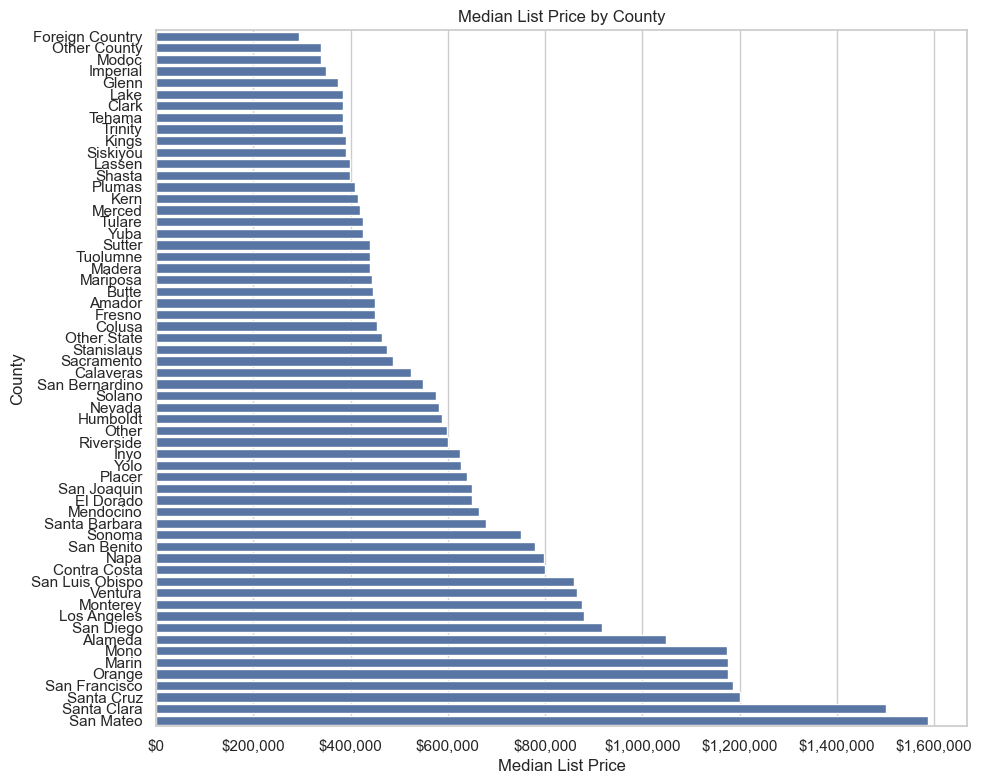

In [79]:
plt.figure(figsize=(10, 8))
ax = sns.barplot(
    data=median_listprice_by_county_df,
    x="MedianListPrice",
    y="CountyOrParish")

ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"${x:,.0f}"))

plt.title("Median List Price by County")
plt.xlabel("Median List Price")
plt.ylabel("County")
plt.tight_layout()
plt.show()

# 6. Segment Analysis

In [80]:
summary_metrics = {"TransactionCount": ("ClosePrice", "size"),
                    "MedianClosePrice": ("ClosePrice", "median"),
                    "MeanClosePrice": ("ClosePrice", "mean"),
                    "MedianOriginalListPrice": ("OriginalListPrice", "median"),
                    "MedianPriceRatio": ("PriceRatio", "median"),
                    "MeanPriceRatio": ("PriceRatio", "mean"),
                    "MedianPricePerSqFt": ("Price_per_sqft", "median"),
                    "MeanPricePerSqFt": ("Price_per_sqft", "mean"),
                    "MedianDaysOnMarket": ("DaysOnMarket", "median"),
                    "MeanDaysOnMarket": ("DaysOnMarket", "mean"),
                    "MedianListingToContractDays": ("Listing_to_Contract_Days", "median"),
                    "MedianContractToCloseDays": ("Contract_to_Close_Days", "median")}

#### 6a) Monthly Summaries

In [81]:
monthly_sold_summary(sold)

,close_yrmo,median_close_price,median_pricesqft,avg_dom,avg_priceratio,homes_sold
0,202401,750000.0,483.397250,37.296838,0.987381,8540
1,202402,790000.0,507.478632,34.087565,1.003342,9867
2,202403,800000.0,514.185788,29.996985,1.012195,11942
3,202404,840000.0,533.477322,27.406490,1.018445,13127
4,202405,850000.0,537.634409,25.396763,1.018790,13963
5,202406,849000.0,538.109121,25.563599,1.013052,12626
6,202407,840000.0,537.300784,27.225693,1.004928,13700
7,202408,830000.0,532.258065,28.538131,0.999337,12811
8,202409,816888.5,526.702290,29.820936,0.996581,11158
9,202410,840000.0,537.099624,31.526832,0.998128,12448


In [82]:
monthly_listing_summary(listings)

,listingcontract_yrmo,new_listings
0,202401,10707
1,202402,9517
2,202403,7423
3,202404,1634
4,202405,1307
5,202406,851
6,202407,708
7,202408,450
8,202409,843
9,202410,1151


#### 6b) Property Sub-type Summary Statistics

In [83]:
propertysubtype_summary = (
    sold.groupby("PropertySubType", dropna=False)
    .agg(**summary_metrics)
    .reset_index()
    .sort_values("TransactionCount", ascending=False))

propertysubtype_summary.head()

,PropertySubType,TransactionCount,MedianClosePrice,MeanClosePrice,MedianOriginalListPrice,MedianPriceRatio,MeanPriceRatio,MedianPricePerSqFt,MeanPricePerSqFt,MedianDaysOnMarket,MeanDaysOnMarket,MedianListingToContractDays,MedianContractToCloseDays
13,SingleFamilyResidence,257728,850000.0,1.001943e+06,850000.0,1.000000,0.998351,518.922636,570.981233,16.0,33.961894,23 days,29 days
2,Condominium,36475,660000.0,7.691170e+05,675000.0,0.986089,0.978167,532.967033,563.856217,25.0,41.944537,30 days,28 days
15,Townhouse,17027,789990.0,9.015414e+05,799000.0,1.000000,0.994306,551.125704,590.974067,17.0,32.495037,22 days,28 days
8,ManufacturedOnLand,2620,420000.0,4.582499e+05,434950.0,0.981802,0.965390,280.448718,297.060305,27.5,54.636641,37 days,35 days
4,Duplex,1596,860000.0,9.640668e+05,882499.5,0.988539,0.980149,540.756318,577.034192,20.0,40.280075,30 days,32 days


#### 6c) County or Parish Summary Statistics

In [84]:
county_summary = (
    sold.groupby("CountyOrParish", dropna=False)
    .agg(**summary_metrics)
    .reset_index()
    .sort_values("TransactionCount", ascending=False))

county_summary.head()

,CountyOrParish,TransactionCount,MedianClosePrice,MeanClosePrice,MedianOriginalListPrice,MedianPriceRatio,MeanPriceRatio,MedianPricePerSqFt,MeanPricePerSqFt,MedianDaysOnMarket,MeanDaysOnMarket,MedianListingToContractDays,MedianContractToCloseDays
18,Los Angeles,82630,885000.0,1.029031e+06,895000.0,1.000000,0.996597,595.259701,636.326747,17.0,33.359034,23 days,30 days
35,Riverside,47890,602390.0,6.535287e+05,614900.0,0.988046,0.977159,322.181805,343.227244,29.0,46.987785,37 days,30 days
29,Orange,32661,1175000.0,1.241062e+06,1190000.0,1.000000,0.993979,669.330669,703.460717,13.0,27.787484,23 days,28 days
38,San Bernardino,32001,550000.0,5.942518e+05,557000.0,0.995547,0.981167,337.852866,351.146272,23.0,43.999906,31 days,32 days
39,San Diego,30699,920000.0,1.051038e+06,929800.0,1.000000,0.988416,577.264654,623.460201,13.0,26.493045,20 days,26 days


In [85]:
geo_summary = geographic_summary(sold, "CountyOrParish")

geo_summary.head()

,homes_sold,median_price,avg_priceratio,median_pricesqft,avg_dom
CountyOrParish,,,,,
Los Angeles,82630,885000.0,0.996597,595.259701,33.359034
Riverside,47890,602390.0,0.977159,322.181805,46.987785
Orange,32661,1175000.0,0.993979,669.330669,27.787484
San Bernardino,32001,550000.0,0.981167,337.852866,43.999906
San Diego,30699,920000.0,0.988416,577.264654,26.493045


#### 6d) MLS Area Major Summary Statistics

In [86]:
mlsarea_summary = (
    sold.groupby("MLSAreaMajor", dropna=False)
    .agg(**summary_metrics)
    .reset_index()
    .sort_values("TransactionCount", ascending=False))

mlsarea_summary.head()

,MLSAreaMajor,TransactionCount,MedianClosePrice,MeanClosePrice,MedianOriginalListPrice,MedianPriceRatio,MeanPriceRatio,MedianPricePerSqFt,MeanPricePerSqFt,MedianDaysOnMarket,MeanDaysOnMarket,MedianListingToContractDays,MedianContractToCloseDays
1041,NaN,46937,815000.0,9.737299e+05,799888.0,1.000000,1.017876,533.841754,570.623451,15.0,31.182393,15 days,25 days
294,699 - Not Defined,29771,1201000.0,1.313749e+06,1198000.0,1.001669,1.020850,746.268657,811.739562,13.0,28.808606,14 days,26 days
917,SRCAR - Southwest Riverside County,17144,590089.0,6.078153e+05,599000.0,1.000000,0.987121,297.183732,309.762972,23.0,40.269540,32 days,31 days
131,252 - Riverside,4478,652245.0,6.792476e+05,659900.0,1.000000,0.988429,386.100386,395.082847,19.0,36.886333,27 days,31 days
653,LAC - Lancaster,2811,475000.0,4.867332e+05,480000.0,1.000000,0.986431,273.985680,279.194067,25.0,40.561722,30 days,34 days


#### 6e) List Office Summary Statistics

In [87]:
listoffice_summary = (
    sold.groupby("ListOfficeName", dropna=False)
    .agg(**summary_metrics)
    .reset_index()
    .sort_values("TransactionCount", ascending=False))

listoffice_summary.head(10)

,ListOfficeName,TransactionCount,MedianClosePrice,MeanClosePrice,MedianOriginalListPrice,MedianPriceRatio,MeanPriceRatio,MedianPricePerSqFt,MeanPricePerSqFt,MedianDaysOnMarket,MeanDaysOnMarket,MedianListingToContractDays,MedianContractToCloseDays
3620,Compass,19687,1258500.0,1.349386e+06,1219000.0,1.000000,1.017997,720.910624,773.031952,13.0,27.479301,15 days,25 days
3543,Coldwell Banker Realty,13238,1145000.0,1.255792e+06,1149000.0,1.000000,1.002494,669.614920,724.812034,15.0,31.638692,20 days,25 days
8149,Keller Williams Realty,6144,870000.0,9.761153e+05,875000.0,1.000000,1.003576,536.458957,560.266955,14.0,29.401204,20 days,27 days
5428,First Team Real Estate,4690,980000.0,1.078284e+06,979000.0,1.000000,0.997117,608.812746,609.087430,12.0,26.697868,25 days,29 days
16838,eXp Realty of California Inc,3874,802250.0,9.284475e+05,800000.0,1.000000,0.994251,528.477219,567.372046,17.0,33.981673,23 days,29 days
1726,Berkshire Hathaway HomeServices California Pro...,3649,895000.0,1.053344e+06,899000.0,0.989054,0.983972,555.975794,605.407922,22.0,39.091258,28 days,28 days
12469,Real Broker,3391,850000.0,9.731114e+05,849900.0,1.000000,0.999119,551.766894,573.646658,14.0,27.961368,23 days,27 days
7161,Intero Real Estate Services,3258,1350000.0,1.413456e+06,1299888.0,1.022453,1.040861,830.212054,878.686031,11.0,23.013505,11 days,25 days
4996,Equity Union,2911,845000.0,9.388243e+05,858000.0,0.981791,0.974932,471.216342,509.829202,27.0,43.834078,31 days,26 days
16841,"eXp Realty of California, Inc.",2481,760000.0,8.810705e+05,752000.0,1.000001,1.003658,478.240077,521.507703,13.0,27.250302,21 days,27 days


In [88]:
list_competitive_summary = competitive_summary(sold, "ListOfficeName")

list_competitive_summary.head(10)

,units_sold,total_volume,median_price,avg_PriceRatio,avg_dom
ListOfficeName,,,,,
Compass,19687,2.656537e+10,1258500.0,1.017997,27.479301
Coldwell Banker Realty,13238,1.662418e+10,1145000.0,1.002494,31.638692
Keller Williams Realty,6144,5.997253e+09,870000.0,1.003576,29.401204
First Team Real Estate,4690,5.057151e+09,980000.0,0.997117,26.697868
eXp Realty of California Inc,3874,3.596805e+09,802250.0,0.994251,33.981673
Berkshire Hathaway HomeServices California Properties,3649,3.843654e+09,895000.0,0.983972,39.091258
Real Broker,3391,3.299821e+09,850000.0,0.999119,27.961368
Intero Real Estate Services,3258,4.605039e+09,1350000.0,1.040861,23.013505
Equity Union,2911,2.732918e+09,845000.0,0.974932,43.834078


#### 6f) Buyer Office Summary Statistics

In [89]:
buyeroffice_summary = (
    sold.groupby("BuyerOfficeName", dropna=False)
    .agg(**summary_metrics)
    .reset_index()
    .sort_values("TransactionCount", ascending=False))

buyeroffice_summary.head(10)

,BuyerOfficeName,TransactionCount,MedianClosePrice,MeanClosePrice,MedianOriginalListPrice,MedianPriceRatio,MeanPriceRatio,MedianPricePerSqFt,MeanPricePerSqFt,MedianDaysOnMarket,MeanDaysOnMarket,MedianListingToContractDays,MedianContractToCloseDays
4099,Compass,18739,1250000.0,1.341894e+06,1216000.0,1.000000,1.013861,716.674630,770.399184,14.0,28.985912,17 days,25 days
4006,Coldwell Banker Realty,10663,1130000.0,1.245413e+06,1128000.0,1.000000,1.002657,661.896243,719.304284,15.0,32.223108,20 days,25 days
11391,NONMEMBER MRML,6653,525000.0,6.172856e+05,534900.0,0.987879,0.977110,293.494705,357.128570,25.0,45.983165,33 days,31 days
9119,Keller Williams Realty,4804,840000.0,9.515139e+05,849000.0,1.000000,0.995500,522.984098,546.098031,15.0,32.449209,22 days,27 days
19042,NaN,4801,1150000.0,1.216230e+06,1088888.0,1.007692,1.027316,729.166667,750.236618,14.0,29.462195,14 days,25 days
14090,Real Broker,4444,812000.0,9.368219e+05,802500.0,1.000000,0.993932,530.605114,556.082435,16.0,32.009451,25 days,28 days
6126,First Team Real Estate,4176,910500.0,1.023680e+06,899999.0,1.000000,0.996322,594.059406,593.242019,13.0,29.358477,24 days,28 days
18933,eXp Realty of California Inc,4156,850000.0,9.710910e+05,850000.0,1.000000,0.993948,565.505893,601.798338,18.0,34.693215,24 days,28 days
18936,"eXp Realty of California, Inc.",3272,745525.0,8.424831e+05,749850.0,1.000000,0.991246,472.274848,509.008901,17.0,33.460269,26 days,27 days
1956,Berkshire Hathaway HomeServices California Pro...,2990,919950.0,1.080940e+06,929000.0,0.992689,0.986939,565.714679,617.825138,19.0,36.489967,26 days,28 days


In [90]:
buyer_competitive_summary = competitive_summary(sold, "BuyerOfficeName")

buyer_competitive_summary.head(10)

,units_sold,total_volume,median_price,avg_PriceRatio,avg_dom
BuyerOfficeName,,,,,
Compass,18739,2.514576e+10,1250000.0,1.013861,28.985912
Coldwell Banker Realty,10663,1.327984e+10,1130000.0,1.002657,32.223108
NONMEMBER MRML,6653,4.106801e+09,525000.0,0.977110,45.983165
Keller Williams Realty,4804,4.571073e+09,840000.0,0.995500,32.449209
Real Broker,4444,4.163237e+09,812000.0,0.993932,32.009451
First Team Real Estate,4176,4.274888e+09,910500.0,0.996322,29.358477
eXp Realty of California Inc,4156,4.035854e+09,850000.0,0.993948,34.693215
"eXp Realty of California, Inc.",3272,2.756605e+09,745525.0,0.991246,33.460269
Berkshire Hathaway HomeServices California Properties,2990,3.232010e+09,919950.0,0.986939,36.489967


#### 6g) Price Tier Summary

In [91]:
price_tier_summary(sold)

,Price_Tier,count,avg_PriceRatio,avg_dom,median_pricesqft,pct_reduced
0,Under 300K,1478,0.847040,94.103518,230.074405,71.718539
1,300K-500K,46166,0.971657,46.859875,296.819015,34.908807
2,500K-750K,89377,0.988034,38.709187,414.588529,30.183381
3,750K-1M,71246,0.994537,32.064649,540.626000,25.091935
4,1M-2M,92137,1.008407,29.126258,711.743772,21.654710
5,2M+,16732,1.043287,23.331281,1017.707454,13.393497


#### 6h) DOM Bucket Summary

In [92]:
dom_bucket_summary(sold)

,DOM_bucket,count,avg_PriceRatio,median_price,pct_above_ask
0,0-7,67775,1.036125,875000.0,0.0
1,8-14,65357,1.037285,900000.0,0.0
2,15-30,60817,0.994039,808000.0,0.0
3,31-60,55455,0.964979,765000.0,0.0
4,61-90,26510,0.944559,732841.0,0.0
5,90+,30220,0.913741,682000.0,0.0


#### 6j) Overall Market Summary

In [93]:
market_summary(sold, listings)

CALIFORNIA RESIDENTIAL MARKET SUMMARY
Period: 2024-01-01 to 2026-04-30
Total closed transactions:    317,136
Total new listings:           116,851
Median close price:           $816,000
Median price per sq ft:       $521
Avg days on market:           35.1
Avg sold/list price ratio:    0.9953
% sold above ask:             51.6%
% with price reduction:       26.6%
Unique cities:                1023
Unique counties:              60
Unique ZIP codes:             3322
Unique listing offices:       16912
Unique listing agents:        69731


### Create a copy of the cleaned versions of listings and sold

In [94]:
listings.to_csv("listings_cleaned.csv", index=False)
sold.to_csv("sold_cleaned.csv", index=False)

In [98]:
# Show all columns
pd.set_option('display.max_columns', None)

# To also prevent line-wrapping for very wide DataFrames
pd.set_option('display.width', None)

# Print or display your DataFrame
sold

,BuyerAgentAOR,ListAgentAOR,Flooring,ViewYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,ListAgentFirstName,ListAgentLastName,Latitude,Longitude,UnparsedAddress,PropertyType,LivingArea,ListPrice,DaysOnMarket,ListOfficeName,BuyerOfficeName,CoListOfficeName,ListAgentFullName,CoListAgentFirstName,CoListAgentLastName,BuyerAgentMlsId,BuyerAgentFirstName,BuyerAgentLastName,AssociationFeeFrequency,ListingKeyNumeric,MLSAreaMajor,CountyOrParish,MlsStatus,ElementarySchool,AttachedGarageYN,ParkingTotal,PropertySubType,LotSizeAcres,SubdivisionName,BuyerOfficeAOR,YearBuilt,StreetNumberNumeric,ListingId,BathroomsTotalInteger,City,BedroomsTotal,ContractStatusChangeDate,PurchaseContractDate,ListingContractDate,StateOrProvince,MiddleOrJuniorSchool,FireplaceYN,Stories,HighSchool,Levels,LotSizeArea,MainLevelBedrooms,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,OriginatingSystemName,OriginatingSystemSubName,BuyerAgencyCompensationType,BuyerAgencyCompensation,latfilled,lonfilled,year_month,rate_30yr_fixed,close_year,close_month,close_day,close_yrmoday,close_yrmo,contractstatuschange_year,contractstatuschange_month,contractstatuschange_day,contractstatuschange_yrmoday,contractstatuschange_yrmo,purchasecontract_year,purchasecontract_month,purchasecontract_day,purchasecontract_yrmoday,purchasecontract_yrmo,listingcontract_year,listingcontract_month,listingcontract_day,listingcontract_yrmoday,listingcontract_yrmo,ClosePrice_outlier,ListPrice_outlier,OriginalListPrice_outlier,LivingArea_outlier,LotSizeAcres_outlier,BedroomsTotal_outlier,BathroomsTotalInteger_outlier,DaysOnMarket_outlier,YearBuilt_outlier,PriceRatio,Price_per_sqft,DOM_bucket,Listing_to_Contract_Days,Contract_to_Close_Days,Market_Condition,Price_Reduction,Was_Reduced,Price_Tier
4,Southland,Southland,NaN,0,0,1890500.0,1075037759,karen.klein@theagencyre.com,2024-01-29,1890500.0,Karen,Klein,34.164376,-118.558749,19524 Winifred Street,Residential,3194.0,1890500.0,0,The Agency,The Agency - Studio City,NaN,Karen Klein,NaN,NaN,GD165115383,Levon,Arzumanyan,NaN,1075037759,TAR - Tarzana,Los Angeles,Closed,NaN,1,2.0,SingleFamilyResidence,0.4103,NaN,Glendale,1955.0,19524.0,SR24091473,3.0,Tarzana,5.0,2024-01-29,2024-01-29,2024-01-29,CA,NaN,1,1.0,NaN,One,17873.0,5.0,0,2.0,Los Angeles Unified,91356,0.00,17873.0,CRMLS,CRMLS_CRM,NaN,NaN,NaN,NaN,2024-01,6.6425,2024,1,29,20240129,202401,2024.0,1.0,29.0,20240129.0,202401.0,2024.0,1.0,29.0,20240129.0,202401.0,2024.0,1.0,29.0,20240129.0,202401.0,False,False,False,False,False,False,False,False,False,1.000000,591.891046,NaN,0 days,0 days,1,0.0,0,1M-2M
8,PasadenaFoothills,PasadenaFoothills,Wood,1,0,999000.0,1061617422,kerry.kimble@theagencyre.com,2024-01-30,1130000.0,Kerry,Kimble,34.070215,-118.258618,1131 W Kensington Road,Residential,2136.0,999000.0,1,The Agency,The Agency,The Agency,Kerry Kimble,Steven,Galindo,p15417,Steven,Galindo,NaN,1061617422,C21 - Silver Lake - Echo Park,Los Angeles,Closed,NaN,0,0.0,Duplex,0.1636,NaN,PasadenaFoothills,1917.0,1131.0,P1-16615,2.0,Los Angeles,4.0,2024-01-30,2024-01-13,2024-01-12,CA,NaN,0,2.0,NaN,Two,7128.0,NaN,0,0.0,NaN,90026,NaN,7128.0,CRMLS,CRMLS_CRF,NaN,NaN,NaN,NaN,2024-01,6.6425,2024,1,30,20240130,202401,2024.0,1.0,30.0,20240130.0,202401.0,2024.0,1.0,13.0,20240113.0,202401.0,2024.0,1.0,12.0,20240112.0,202401.0,False,False,False,False,False,False,False,False,False,1.131131,529.026217,0-7,1 days,17 days,1,0.0,0,1M-2M
9,BeverlyHillsGreaterLa,BeverlyHillsGreaterLa,Wood,1,0,1050000.0,1060223286,aliciao@kw.com,2024-01-16,1060000.0,Alicia,Ota,34.107850,-118.219273,3707 Primavera Avenue,Residential,1917.0,1050000.0,34,Keller Williams Realty Los Feliz,Keller Williams Realty Los Feliz,NaN,Alicia Ota,NaN,NaN,CLW-C142854,Alicia,Ota,NaN,1060223286,680 - Mount Washington,Los Angeles,Closed,NaN,1,2.0,SingleFamilyResidence,0.2991,NaN,BeverlyHillsGreaterLa,1965.0,3707.0,24356357,3.0,Los Angeles,3.0,2024-01-16,2024-01-10,2023-12-07,CA,NaN,1,NaN,NaN,ThreeOr